# **🎯 Optimized Multi-Label Random Forest (Baseline vs. Optuna)**
# # Random Forest Classifier for Toxic Comment Detection
# 
# **Objective:** Train and evaluate Random Forest model and Opimize using Optuna

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from datetime import datetime

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")
print(f"⏰ Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Libraries loaded successfully!
⏰ Started at: 2025-11-25 15:42:52


## Load Preprocessed Data

In [2]:
# Load train and test data
train_df = pd.read_csv('train_data_2.csv')
test_df = pd.read_csv('test_data_2.csv')

print(f"📊 Training set: {len(train_df)} samples")
print(f"📊 Test set: {len(test_df)} samples")

# Load TF-IDF vectorizers
tfidf_unigram = joblib.load('tfidf_vectorizer_unigram_2.pkl')
tfidf_bigram = joblib.load('tfidf_vectorizer_bigram_2.pkl')

print("\n✅ Data and vectorizers loaded!")

📊 Training set: 800 samples
📊 Test set: 200 samples

✅ Data and vectorizers loaded!


## Prepare Features

In [3]:
# We'll use bigram TF-IDF features (better performance)
X_train = tfidf_bigram.transform(train_df['text'])
X_test = tfidf_bigram.transform(test_df['text'])

target_cols = [
    'IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 
    'IsHatespeech', 'IsRacist', 'IsThreat', 'IsReligiousHate',
    'IsNationalist', 'IsSexist'
]

y_train = train_df[target_cols]
y_test = test_df[target_cols]


print(f"Feature matrix shape: {X_train.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"\nClass distribution in training:")
print(y_train.value_counts())
print(f"\nClass distribution in test:")
print(y_test.value_counts())

Feature matrix shape: (800, 2601)
Number of features: 2601

Class distribution in training:
IsToxic  IsAbusive  IsProvocative  IsObscene  IsHatespeech  IsRacist  IsThreat  IsReligiousHate  IsNationalist  IsSexist
False    False      False          False      False         False     False     False            False          False       430
True     True       True           False      False         False     False     False            False          False        95
         False      False          False      True          True      False     False            False          False        76
         True       False          False      False         False     False     False            False          False        74
                                   True       False         False     False     False            False          False        53
                    True           True       False         False     False     False            False          False        21
                   

## Train Random Forest - Baseline

In [4]:
print("🌲 Training Random Forest Classifier (Baseline)...")
print("This may take 2-5 minutes...\n")

start_time = time.time()

# Initialize Random Forest with default parameters
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train model
rf_baseline.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"\n✅ Training completed in {training_time:.2f} seconds")

🌲 Training Random Forest Classifier (Baseline)...
This may take 2-5 minutes...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.4s



✅ Training completed in 1.70 seconds


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.6s finished


## Evaluate Baseline Model

In [ ]:
## Evaluate Baseline Model (FIXED FOR MULTI-LABEL)

from sklearn.model_selection import StratifiedKFold # Make sure this is imported

print("Calculating Multi-Label Predictions and Probabilities...")

# Make hard predictions (0 or 1)
# y_train_pred will be a numpy array of shape (N_samples, N_labels)
y_train_pred = rf_baseline.predict(X_train)
y_test_pred = rf_baseline.predict(X_test)


# Get Probabilities (soft predictions)
# rf_baseline.predict_proba returns a LIST of arrays (one for each label).
# We need to stack them and select the probability for the POSITIVE class (index 1) for each label.
# np.stack will give us a shape like (N_labels, N_samples, 2).
# We transpose it to (N_samples, N_labels) and select the second column (index 1) from the last dimension.

y_train_proba = np.stack([p[:, 1] for p in rf_baseline.predict_proba(X_train)], axis=1)
y_test_proba = np.stack([p[:, 1] for p in rf_baseline.predict_proba(X_test)], axis=1)

print(f"✅ Multi-label predictions generated. Shape: {y_test_pred.shape}")
print(f"✅ Multi-label probabilities generated. Shape: {y_test_proba.shape}")

# Optional: You can still calculate CV F1-Score, but it requires wrapping the model 
# in a multi-label compatible framework (like OneVsRest or just calling cross_val_score on each label)
# For simplicity, we'll calculate CV metrics later in the summary, focusing on test set now.

Calculating Multi-Label Predictions and Probabilities...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


✅ Multi-label predictions generated. Shape: (200, 10)
✅ Multi-label probabilities generated. Shape: (200, 10)


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


## Calculate Multi-Label Metrics (ROBUST FIX)

In [ ]:
## Calculate Multi-Label Metrics (ROBUST FIX)

# Macro-average treats all classes equally (good for imbalanced labels)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
test_precision_macro = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
test_recall_macro = recall_score(y_test, y_test_pred, average='macro', zero_division=0)

# Micro-average aggregates contributions of all classes
test_f1_micro = f1_score(y_test, y_test_pred, average='micro', zero_division=0)

# Calculate Training F1-Score (to assess overfitting)
train_f1_macro = f1_score(y_train, y_train_pred, average='macro', zero_division=0)

# --- FIX: ROBUST ROC-AUC CALCULATION ---
# This function calculates ROC-AUC per label and averages, ignoring labels where only one class is present.
try:
    # 1. Identify labels that have variance in the test set (needed for AUC)
    valid_labels = y_test.columns[y_test.nunique() > 1].to_list()
    
    if valid_labels:
        # 2. Filter predictions and probabilities to only include valid labels
        y_test_valid = y_test[valid_labels]
        # We need to find the indices of valid columns in the original y_test_proba array
        valid_indices = [y_test.columns.get_loc(label) for label in valid_labels]
        y_test_proba_valid = y_test_proba[:, valid_indices]

        # 3. Calculate AUC only on the valid labels
        test_auc_macro = roc_auc_score(y_test_valid, y_test_proba_valid, average='macro', labels=valid_labels)
        test_auc_weighted = roc_auc_score(y_test_valid, y_test_proba_valid, average='weighted', labels=valid_labels)
    else:
        # Fallback if no valid labels for AUC exist (shouldn't happen with IsToxic)
        test_auc_macro = np.nan
        test_auc_weighted = np.nan

except Exception as e:
    # Final fallback if something unexpected goes wrong
    print(f"\n⚠️ ROC-AUC calculation failed completely: {e}")
    test_auc_macro = np.nan
    test_auc_weighted = np.nan
# --- END ROC-AUC FIX ---

# ... (lines above are correct)

# Cross-Validation F1 (Run for the 'IsToxic' label as a baseline)
print("\nCalculating Cross-Validation F1-Score (IsToxic Baseline)...")

# FIX: You must include the line that calculates cv_scores here.
# Assuming you want to use the first estimator (for 'IsToxic') for the baseline CV.
from sklearn.model_selection import cross_val_score, StratifiedKFold # Ensure these are imported in your setup

# Note: rf_baseline is a MultiOutputClassifier, but cross_val_score expects a single output for scoring.
# We use the first estimator (for the 'IsToxic' label) for this baseline CV score.
cv_scores = cross_val_score(
    rf_baseline.estimators_[0], 
    X_train, 
    y_train['IsToxic'], 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
    scoring='f1', 
    n_jobs=-1
)

# Calculate Overfit Gap
# We use the Macro F1 for Test and Train to get a true multi-label gap.
overfit_gap = (train_f1_macro - test_f1_macro) / train_f1_macro
overfit_diff_absolute = train_f1_macro - test_f1_macro


print("================================================================================")
print("📋 RANDOM FOREST MULTI-LABEL MODEL SUMMARY")
print("================================================================================")
print(f"✅ Model Type: Random Forest Multi-Output Classifier")
print(f"✅ Features: TF-IDF Bigrams ({X_train.shape[1]} features)")
print(f"✅ Training samples: {X_train.shape[0]}")
print(f"✅ Test samples: {X_test.shape[0]}")
print(f"✅ Number of Labels: {len(y_test.columns)}")

print("\n📊 Performance Metrics (Macro-Average):")
print(f"  - Test Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  - Test F1-Score:  {test_f1_macro:.4f} (Macro)")
print(f"  - Test Precision: {test_precision_macro:.4f} (Macro)")
print(f"  - Test Recall:    {test_recall_macro:.4f} (Macro)")
print(f"  - Test ROC-AUC:   {test_auc_macro:.4f} (Macro)")

print("\n📊 Other Metrics:")
print(f"  - CV F1-Score (IsToxic): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"  - Overfit Gap (Macro F1): {overfit_diff_absolute:.4f} ({overfit_gap * 100:.2f}%)")

print(f"\n⏱️ Training Time: {training_time:.2f} seconds")

print("\n📝 Classification Report (Averages across all labels):")
print(classification_report(y_test, y_test_pred, target_names=y_test.columns.to_list(), zero_division=0))


Calculating Cross-Validation F1-Score (IsToxic Baseline)...
📋 RANDOM FOREST MULTI-LABEL MODEL SUMMARY
✅ Model Type: Random Forest Multi-Output Classifier
✅ Features: TF-IDF Bigrams (2601 features)
✅ Training samples: 800
✅ Test samples: 200
✅ Number of Labels: 10

📊 Performance Metrics (Macro-Average):
  - Test Accuracy:  0.5250
  - Test F1-Score:  0.1686 (Macro)
  - Test Precision: 0.4878 (Macro)
  - Test Recall:    0.1181 (Macro)
  - Test ROC-AUC:   0.7783 (Macro)

📊 Other Metrics:
  - CV F1-Score (IsToxic): 0.6080 (+/- 0.0392)
  - Overfit Gap (Macro F1): 0.8152 (82.86%)

⏱️ Training Time: 1.70 seconds

📝 Classification Report (Averages across all labels):
                 precision    recall  f1-score   support

        IsToxic       0.80      0.52      0.63        92
      IsAbusive       0.83      0.34      0.48        71
  IsProvocative       1.00      0.07      0.13        28
      IsObscene       0.25      0.07      0.11        15
   IsHatespeech       1.00      0.08      0.15

## Overfitting Check (Multi-Label)

In [ ]:
## Overfitting Check (Multi-Label)

from sklearn.metrics import f1_score

# 1. Calculate the Macro F1-Score for the training set
train_f1_macro = f1_score(y_train, y_train_pred, average='macro', zero_division=0)

# 2. Calculate the Macro F1-Score for the test set
test_f1_macro = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

# 3. Calculate the difference (Overfit Gap)
overfit_diff_f1 = train_f1_macro - test_f1_macro

print("=========================================")
print("⚠️ Multi-Label Overfitting Check (Macro F1)")
print("=========================================")
print(f"  Training Macro F1: {train_f1_macro:.4f}")
print(f"  Test Macro F1:     {test_f1_macro:.4f}")
print(f"  Overfit Gap:       {overfit_diff_f1:.4f} ({overfit_diff_f1 * 100:.2f}%)")

# Note: For F1-Score, a larger difference often means worse overfitting. 
# The threshold of 5% (0.05) is still a reasonable guideline.
if overfit_diff_f1 < 0.05:
    print("  ✅ Good generalization (F1 difference < 5%)")
elif overfit_diff_f1 < 0.15:
    print("  🟡 Moderate overfitting (5% ≤ F1 difference < 15%)")
else:
    print("  🚨 High overfitting (F1 difference ≥ 15%)")


⚠️ Multi-Label Overfitting Check (Macro F1)
  Training Macro F1: 0.9838
  Test Macro F1:     0.1686
  Overfit Gap:       0.8152 (81.52%)
  🚨 High overfitting (F1 difference ≥ 15%)


## Multi-Label Classification Report

In [ ]:
## Multi-Label Classification Report

# y_test is the DataFrame of true labels (10 columns)
# y_test_pred is the prediction array (N_samples, 10 columns)
# y_test.columns.to_list() provides the correct list of 10 target names
print("\n📋 Detailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=y_test.columns.to_list(), zero_division=0))


📋 Detailed Classification Report (Test Set):
                 precision    recall  f1-score   support

        IsToxic       0.80      0.52      0.63        92
      IsAbusive       0.83      0.34      0.48        71
  IsProvocative       1.00      0.07      0.13        28
      IsObscene       0.25      0.07      0.11        15
   IsHatespeech       1.00      0.08      0.15        24
       IsRacist       1.00      0.10      0.18        20
       IsThreat       0.00      0.00      0.00         7
IsReligiousHate       0.00      0.00      0.00         5
  IsNationalist       0.00      0.00      0.00         2
       IsSexist       0.00      0.00      0.00         0

      micro avg       0.80      0.30      0.44       264
      macro avg       0.49      0.12      0.17       264
   weighted avg       0.79      0.30      0.40       264
    samples avg       0.23      0.14      0.17       264



📊 Multi-Label Confusion Matrices

In [ ]:
Generate and Display Confusion Matrices (Per Label)

from sklearn.metrics import multilabel_confusion_matrix
import numpy as np

# 'y_test' is the DataFrame of true labels (N_samples, 10 columns)
# 'y_test_pred' is the prediction array (N_samples, 10 columns)
target_cols = y_test.columns.to_list()

print("=========================================")
print("📋 Confusion Matrix Per Label (Test Set)")
print("=========================================")

# Calculate all 10 confusion matrices at once
# matrix_array will have shape (10, 2, 2)
matrix_array = multilabel_confusion_matrix(y_test, y_test_pred)

# Iterate through the matrices and their corresponding labels
for i, label in enumerate(target_cols):
    cm = matrix_array[i]
    
    # Extract values:
    # cm[0, 0] = True Negatives (TN)
    # cm[0, 1] = False Positives (FP)
    # cm[1, 0] = False Negatives (FN)
    # cm[1, 1] = True Positives (TP)
    
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]
    
    # Calculate support for the positive class (TP + FN)
    support_positive = TP + FN
    
    print(f"\n--- Label: {label} (Support: {support_positive}) ---")
    print(f"| {TN:4} (TN) | {FP:4} (FP) |")
    print(f"| {FN:4} (FN) | {TP:4} (TP) |")

    # Optional: Check if the label is too sparse
    if support_positive == 0:
        print("  ⚠️ Warning: No positive samples for this label in the test set.")

📋 Confusion Matrix Per Label (Test Set)

--- Label: IsToxic (Support: 92) ---
|   96 (TN) |   12 (FP) |
|   44 (FN) |   48 (TP) |

--- Label: IsAbusive (Support: 71) ---
|  124 (TN) |    5 (FP) |
|   47 (FN) |   24 (TP) |

--- Label: IsProvocative (Support: 28) ---
|  172 (TN) |    0 (FP) |
|   26 (FN) |    2 (TP) |

--- Label: IsObscene (Support: 15) ---
|  182 (TN) |    3 (FP) |
|   14 (FN) |    1 (TP) |

--- Label: IsHatespeech (Support: 24) ---
|  176 (TN) |    0 (FP) |
|   22 (FN) |    2 (TP) |

--- Label: IsRacist (Support: 20) ---
|  180 (TN) |    0 (FP) |
|   18 (FN) |    2 (TP) |

--- Label: IsThreat (Support: 7) ---
|  193 (TN) |    0 (FP) |
|    7 (FN) |    0 (TP) |

--- Label: IsReligiousHate (Support: 5) ---
|  195 (TN) |    0 (FP) |
|    5 (FN) |    0 (TP) |

--- Label: IsNationalist (Support: 2) ---
|  198 (TN) |    0 (FP) |
|    2 (FN) |    0 (TP) |

--- Label: IsSexist (Support: 0) ---
|  200 (TN) |    0 (FP) |
|    0 (FN) |    0 (TP) |
  ⚠️ Warning: No positive sample

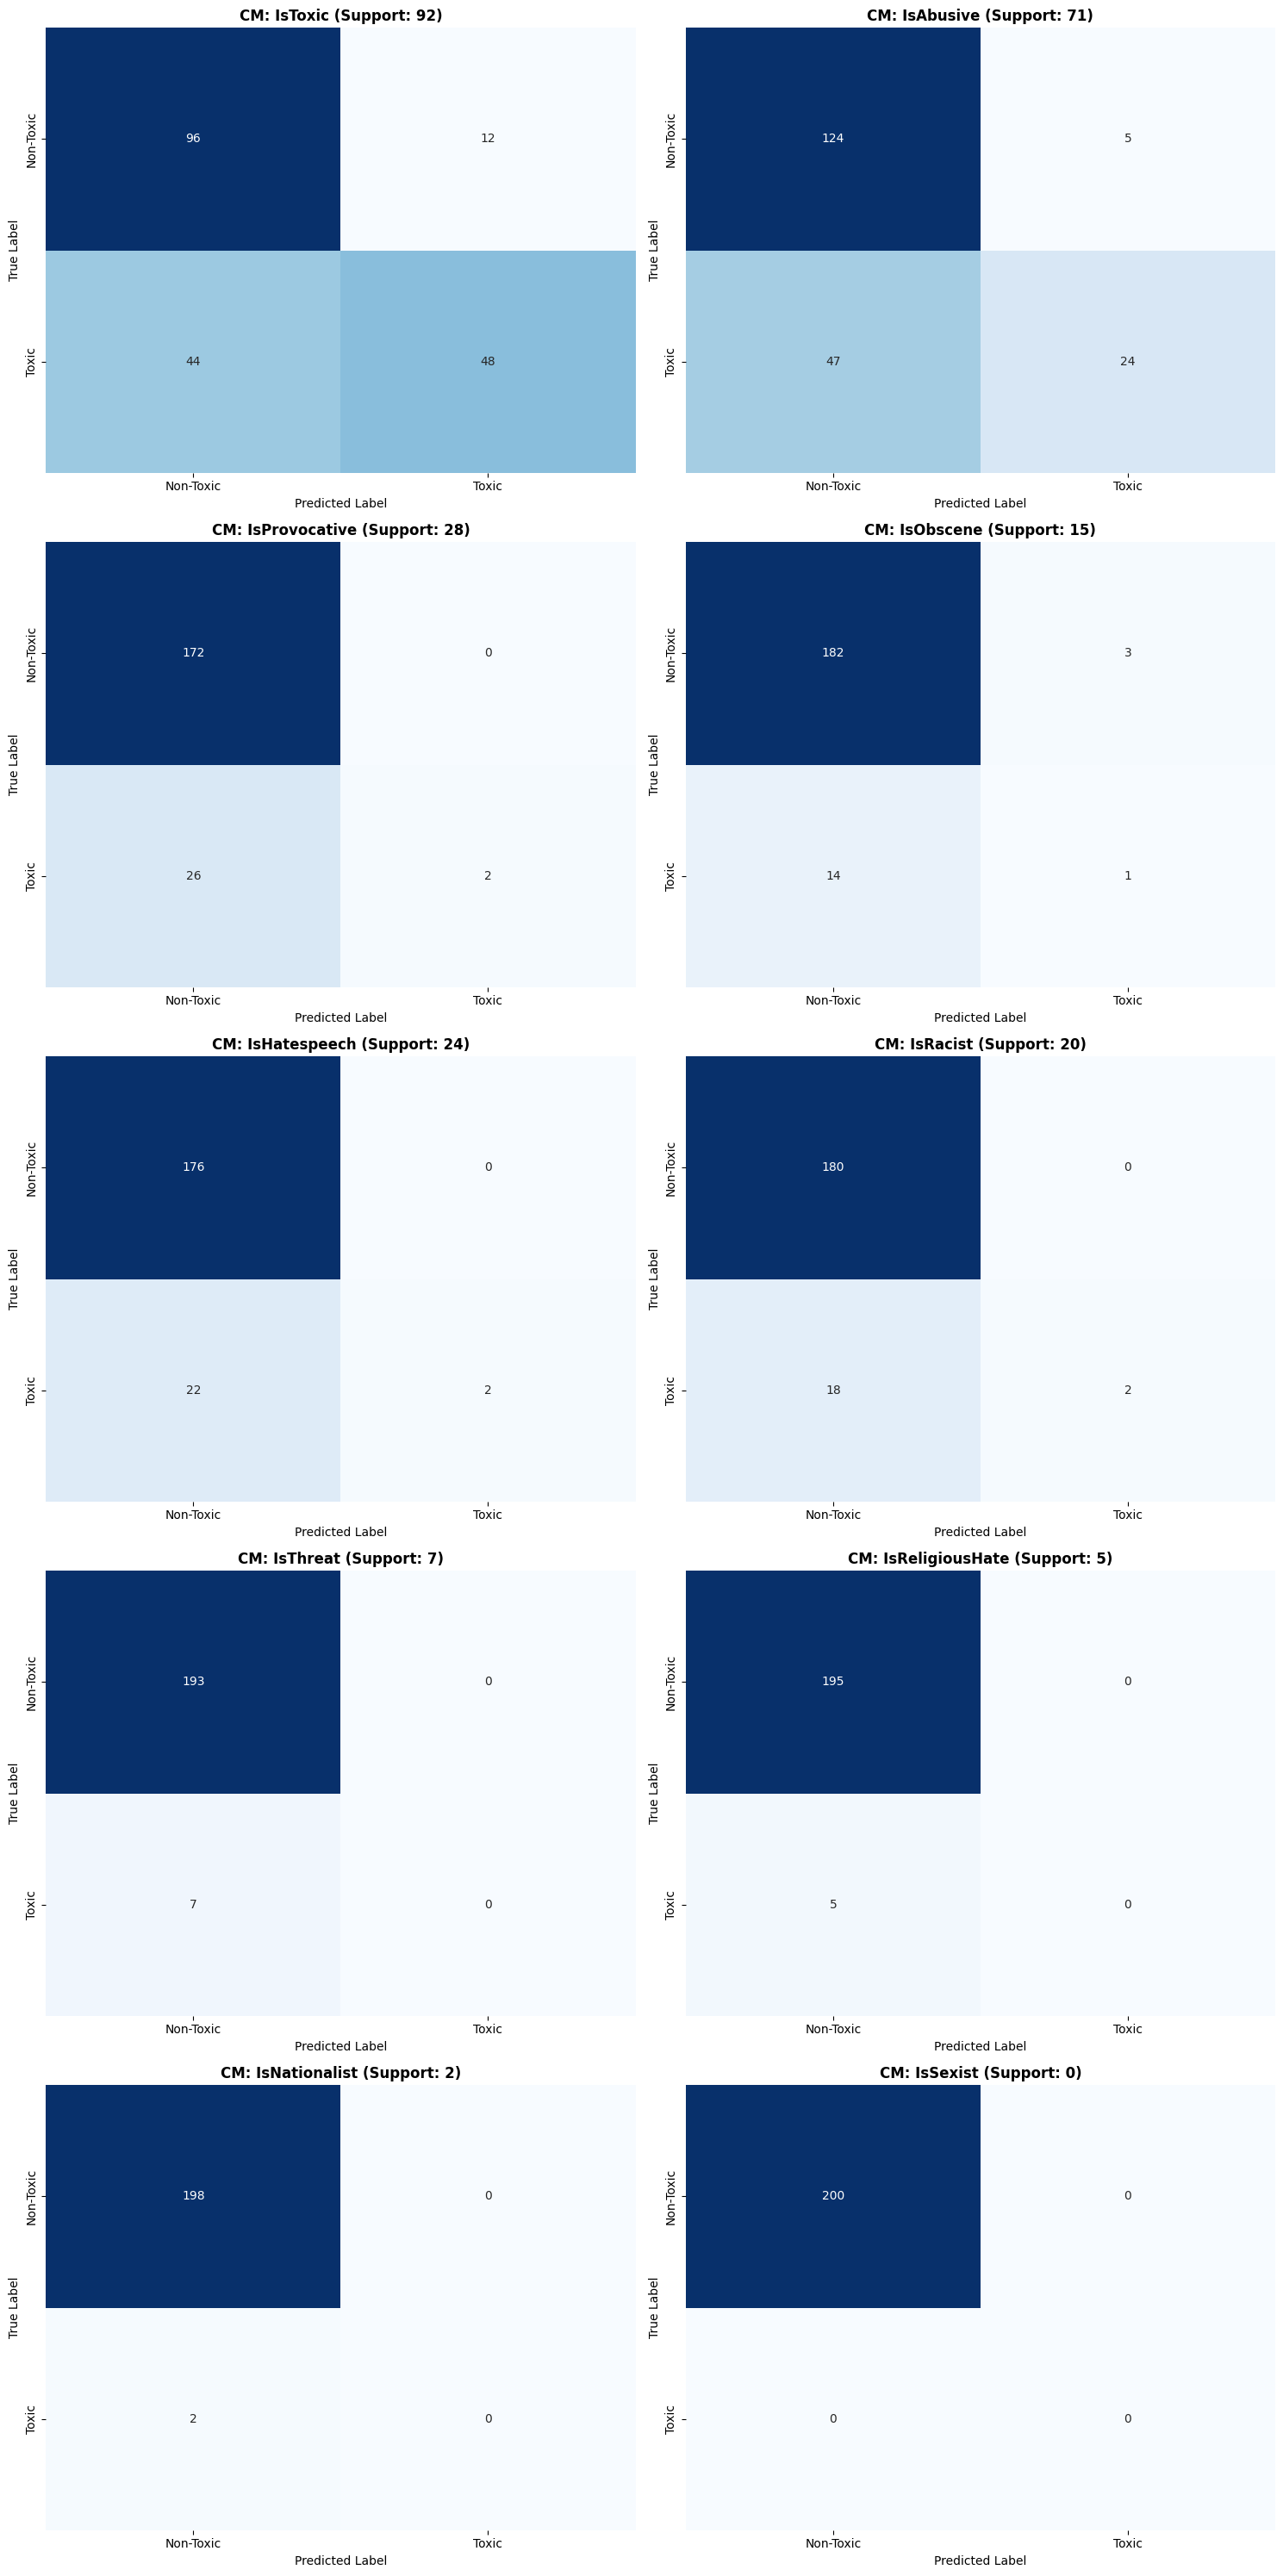

In [12]:
## 10. Generate Heatmaps for All 10 Confusion Matrices

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

# Assume y_test and y_test_pred are correctly defined multi-label DataFrames/arrays
target_cols = y_test.columns.to_list()
matrix_array = multilabel_confusion_matrix(y_test, y_test_pred)
n_labels = len(target_cols)

# Set up a large figure to display all 10 matrices (e.g., 5 rows x 2 columns)
fig, axes = plt.subplots(5, 2, figsize=(15, 30))
axes = axes.flatten()  # Flattens the 5x2 array of axes for easy iteration

for i, cm in enumerate(matrix_array):
    label = target_cols[i]
    ax = axes[i]
    
    # Use seaborn to create the heatmap for the current label
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        cbar=False, # We can turn off the color bar to save space
        xticklabels=['Non-Toxic', 'Toxic'],
        yticklabels=['Non-Toxic', 'Toxic'],
        ax=ax
    )
    
    ax.set_title(f'CM: {label} (Support: {cm[1,0] + cm[1,1]})', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

# Hide any unused subplots if n_labels is less than 10
if n_labels < len(axes):
    for j in range(n_labels, len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 6. Feature Importance Analysis

In [ ]:
## Feature Importance Analysis and Top 5 Print (Combined)

import pandas as pd
import numpy as np

# --- 1. Load Feature Names ---
# Assuming 'tfidf_bigram', 'y_test', and 'rf_baseline' are available
feature_names = tfidf_bigram.get_feature_names_out()
target_cols = y_test.columns.to_list()
n_features = len(feature_names)

print("=========================================")
print("📋 Feature Importance Analysis Setup")
print("=========================================")
print(f"Total features: {n_features}")
print(f"Number of labels (estimators): {len(rf_baseline.estimators_)}")
print("=========================================")
print("🎯 Extracting Feature Importances...")
print("=========================================")

# --- 2. Iterate Through Each Estimator (Label) and Print Top 5 ---
# The loops and calculation logic are moved here from the old 11B
for i, (label, estimator) in enumerate(zip(target_cols, rf_baseline.estimators_)):
    
    # Get feature importances for the current label's model
    importances = estimator.feature_importances_
    
    # Create a DataFrame for easy sorting
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    
    # Select the top 5 features for console review
    top_5_features = feature_importance_df.head(5)
    
    # Print the top 5 features
    print(f"\n--- Top 5 Features for Label: {label} ---")
    print(top_5_features.to_string(index=False))

📋 Feature Importance Analysis Setup
Total features: 2601
Number of labels (estimators): 100
🎯 Extracting Feature Importances...

--- Top 5 Features for Label: IsToxic ---
feature  importance
   fuck    0.056280
  would    0.026404
    run    0.025339
  idiot    0.022751
   high    0.018605

--- Top 5 Features for Label: IsAbusive ---
feature  importance
  white    0.072143
    run    0.034073
   shit    0.024635
 happen    0.022131
   arab    0.019237

--- Top 5 Features for Label: IsProvocative ---
feature  importance
    run    0.057170
   shit    0.039636
   fuck    0.036191
  white    0.019301
  idiot    0.018335

--- Top 5 Features for Label: IsObscene ---
feature  importance
    run    0.034851
   shit    0.032998
  would    0.024261
   fuck    0.020237
    isi    0.020080

--- Top 5 Features for Label: IsHatespeech ---
feature  importance
  white    0.036113
  black    0.034510
   thug    0.029811
fucking    0.024253
    run    0.018101

--- Top 5 Features for Label: IsRacist --


📊 Generating 10 Feature Importance Plots...


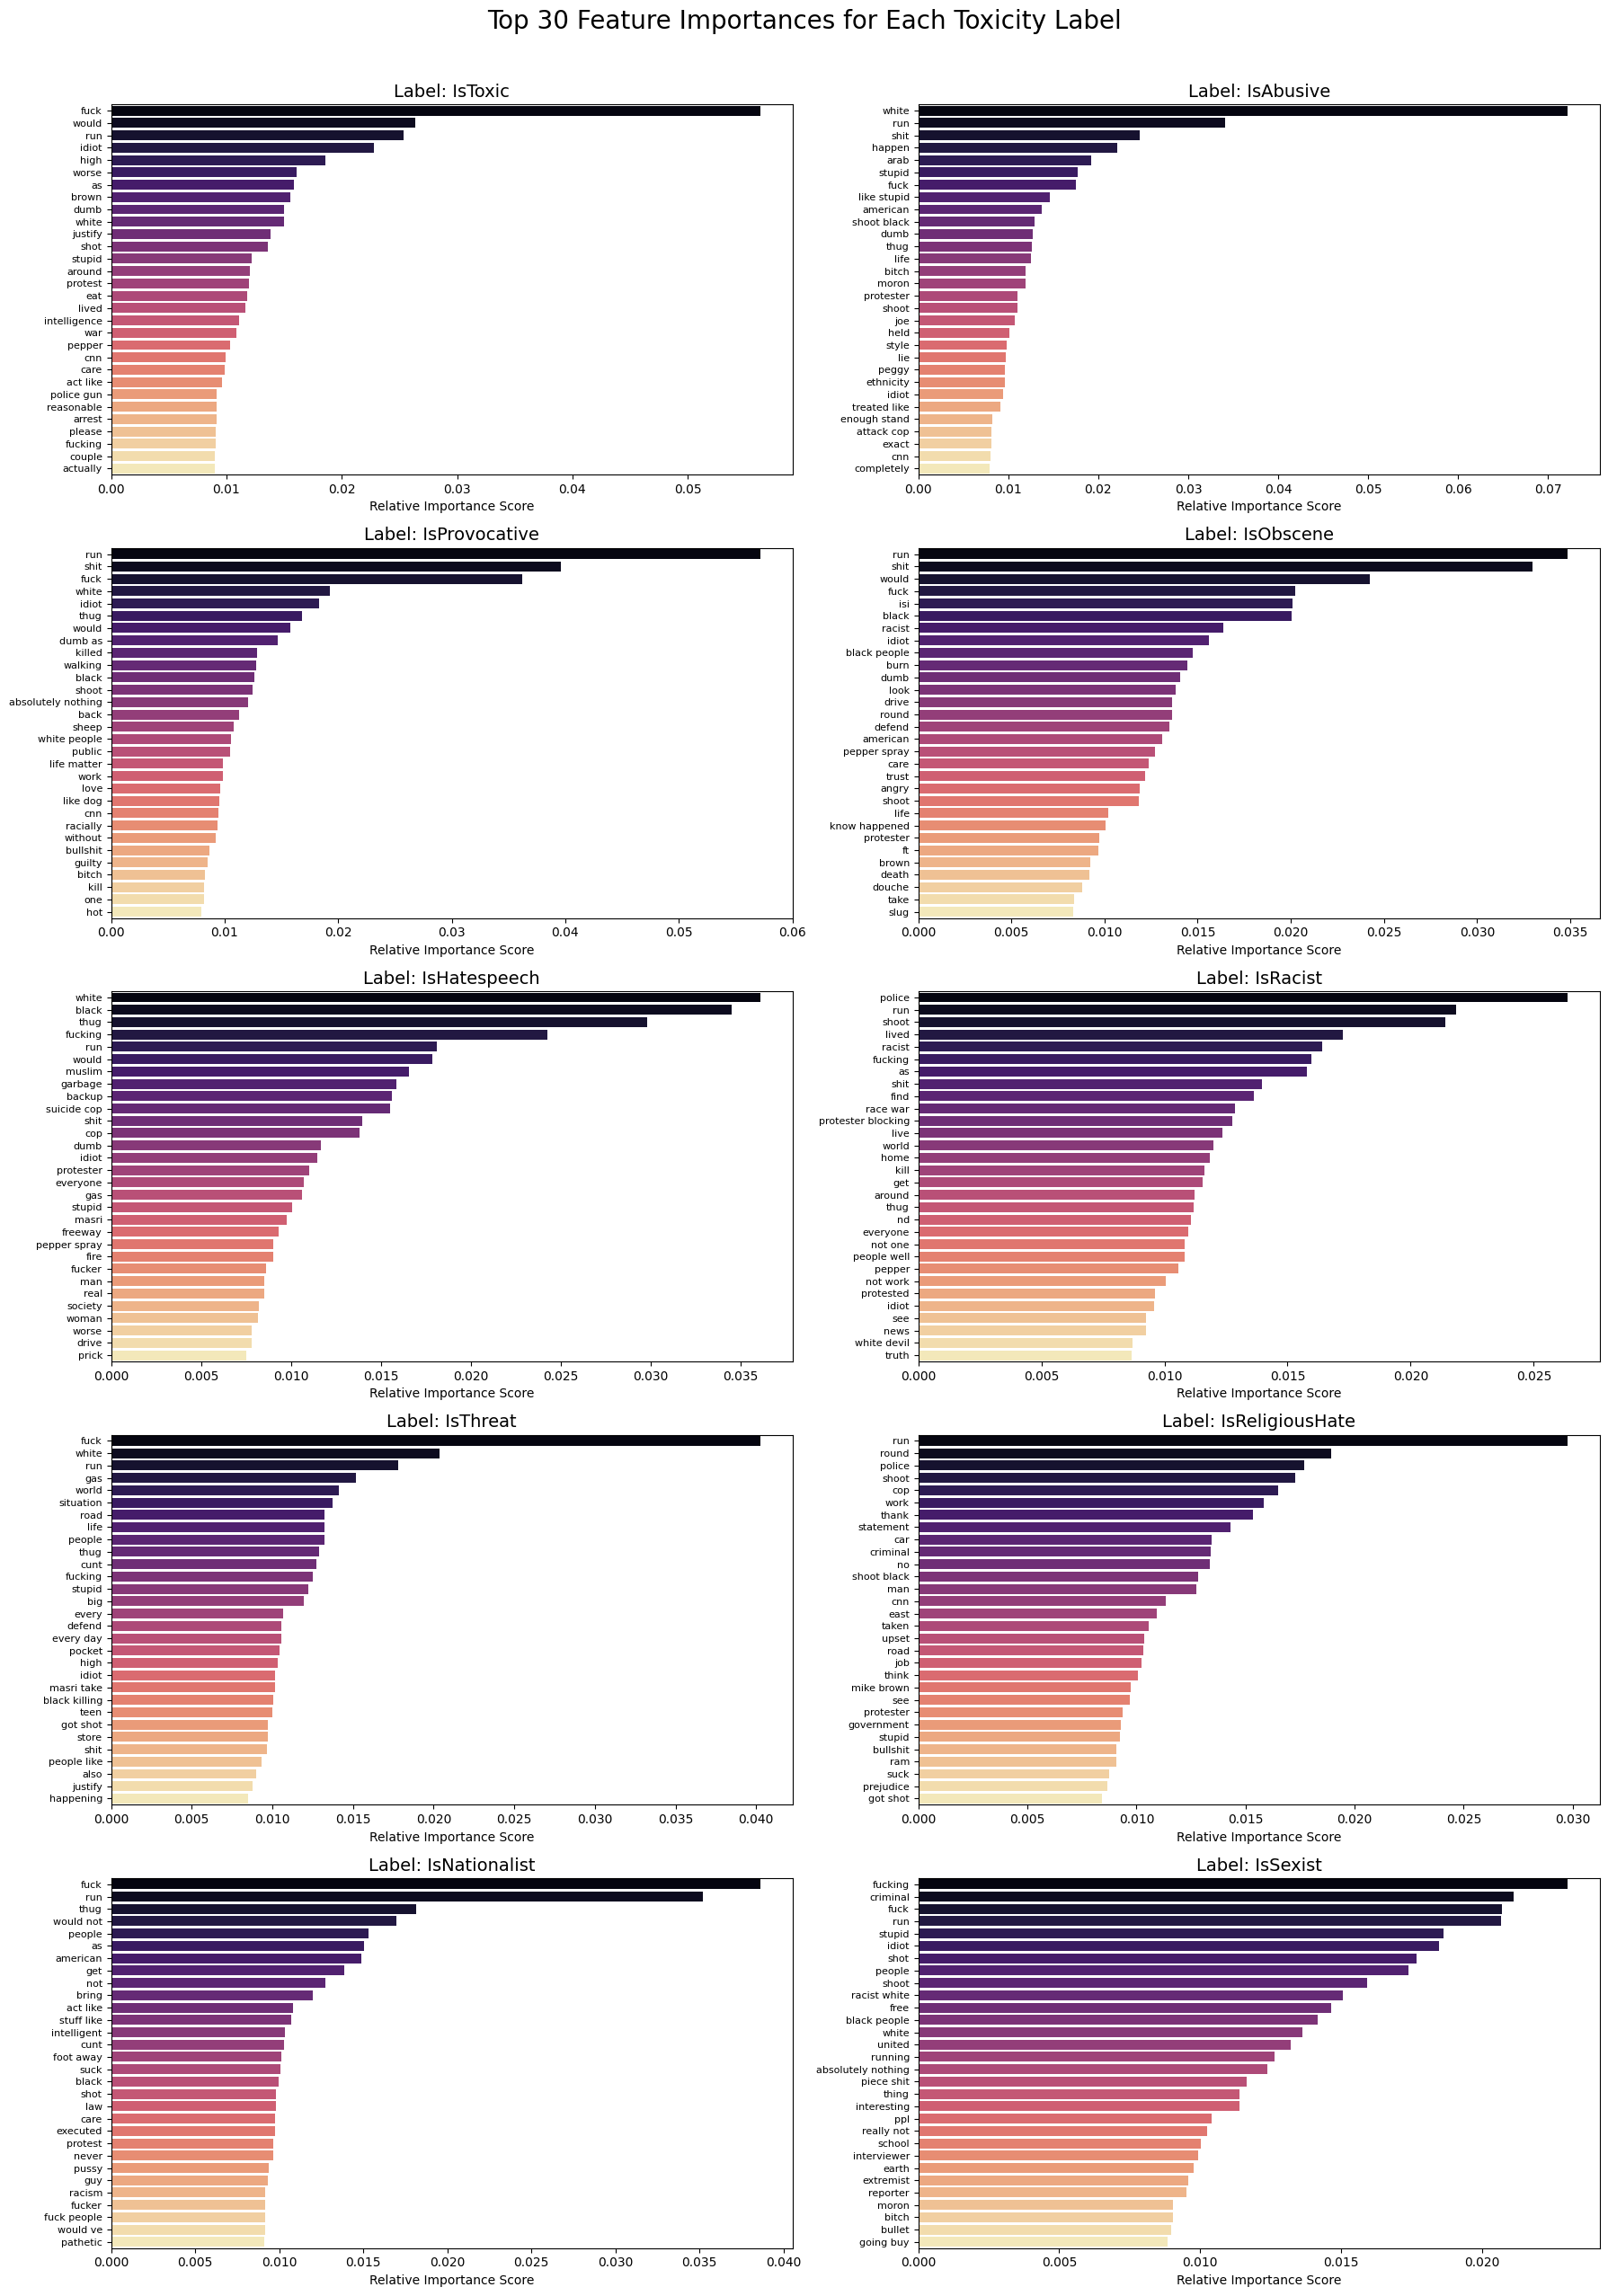


✅ Plot generation complete.


In [ ]:
## Feature Importance Calculation and Visualization (FIXED - Visualization Only)

# --- 2. Setup Plotting Environment ---
# We will create a 5x2 grid for 10 plots
fig, axes = plt.subplots(5, 2, figsize=(18, 25))
axes = axes.flatten()
plt.suptitle('Top 30 Feature Importances for Each Toxicity Label', fontsize=20, y=1.02)

print("\n=========================================")
print("📊 Generating 10 Feature Importance Plots...")
print("=========================================")

# --- 3. Iterate Through Each Estimator (Label) ---
for i, (label, estimator) in enumerate(zip(target_cols, rf_baseline.estimators_)):
    
    # Get feature importances for the current label's model
    importances = estimator.feature_importances_
    
    # Create a DataFrame for easy sorting
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    
    # Select the top 30 features
    top_30_features = feature_importance_df.head(30)
    
    # --- 4. Plotting ---
    ax = axes[i]
    sns.barplot(
        x='importance', 
        y='feature', 
        data=top_30_features, 
        ax=ax, 
        palette='magma' # Use a distinct color palette
    )
    ax.set_title(f'Label: {label}', fontsize=14)
    ax.set_xlabel('Relative Importance Score')
    ax.set_ylabel('') # Clear y-axis label (features are the labels)
    ax.tick_params(axis='y', labelsize=8) # Smaller font for features

# --- 5. Final Display ---
plt.tight_layout(rect=[0, 0, 1, 1.01]) # Adjust layout to make space for suptitle
plt.show()

print("\n✅ Plot generation complete.")

## ROC Curve Analysis (Per Label)

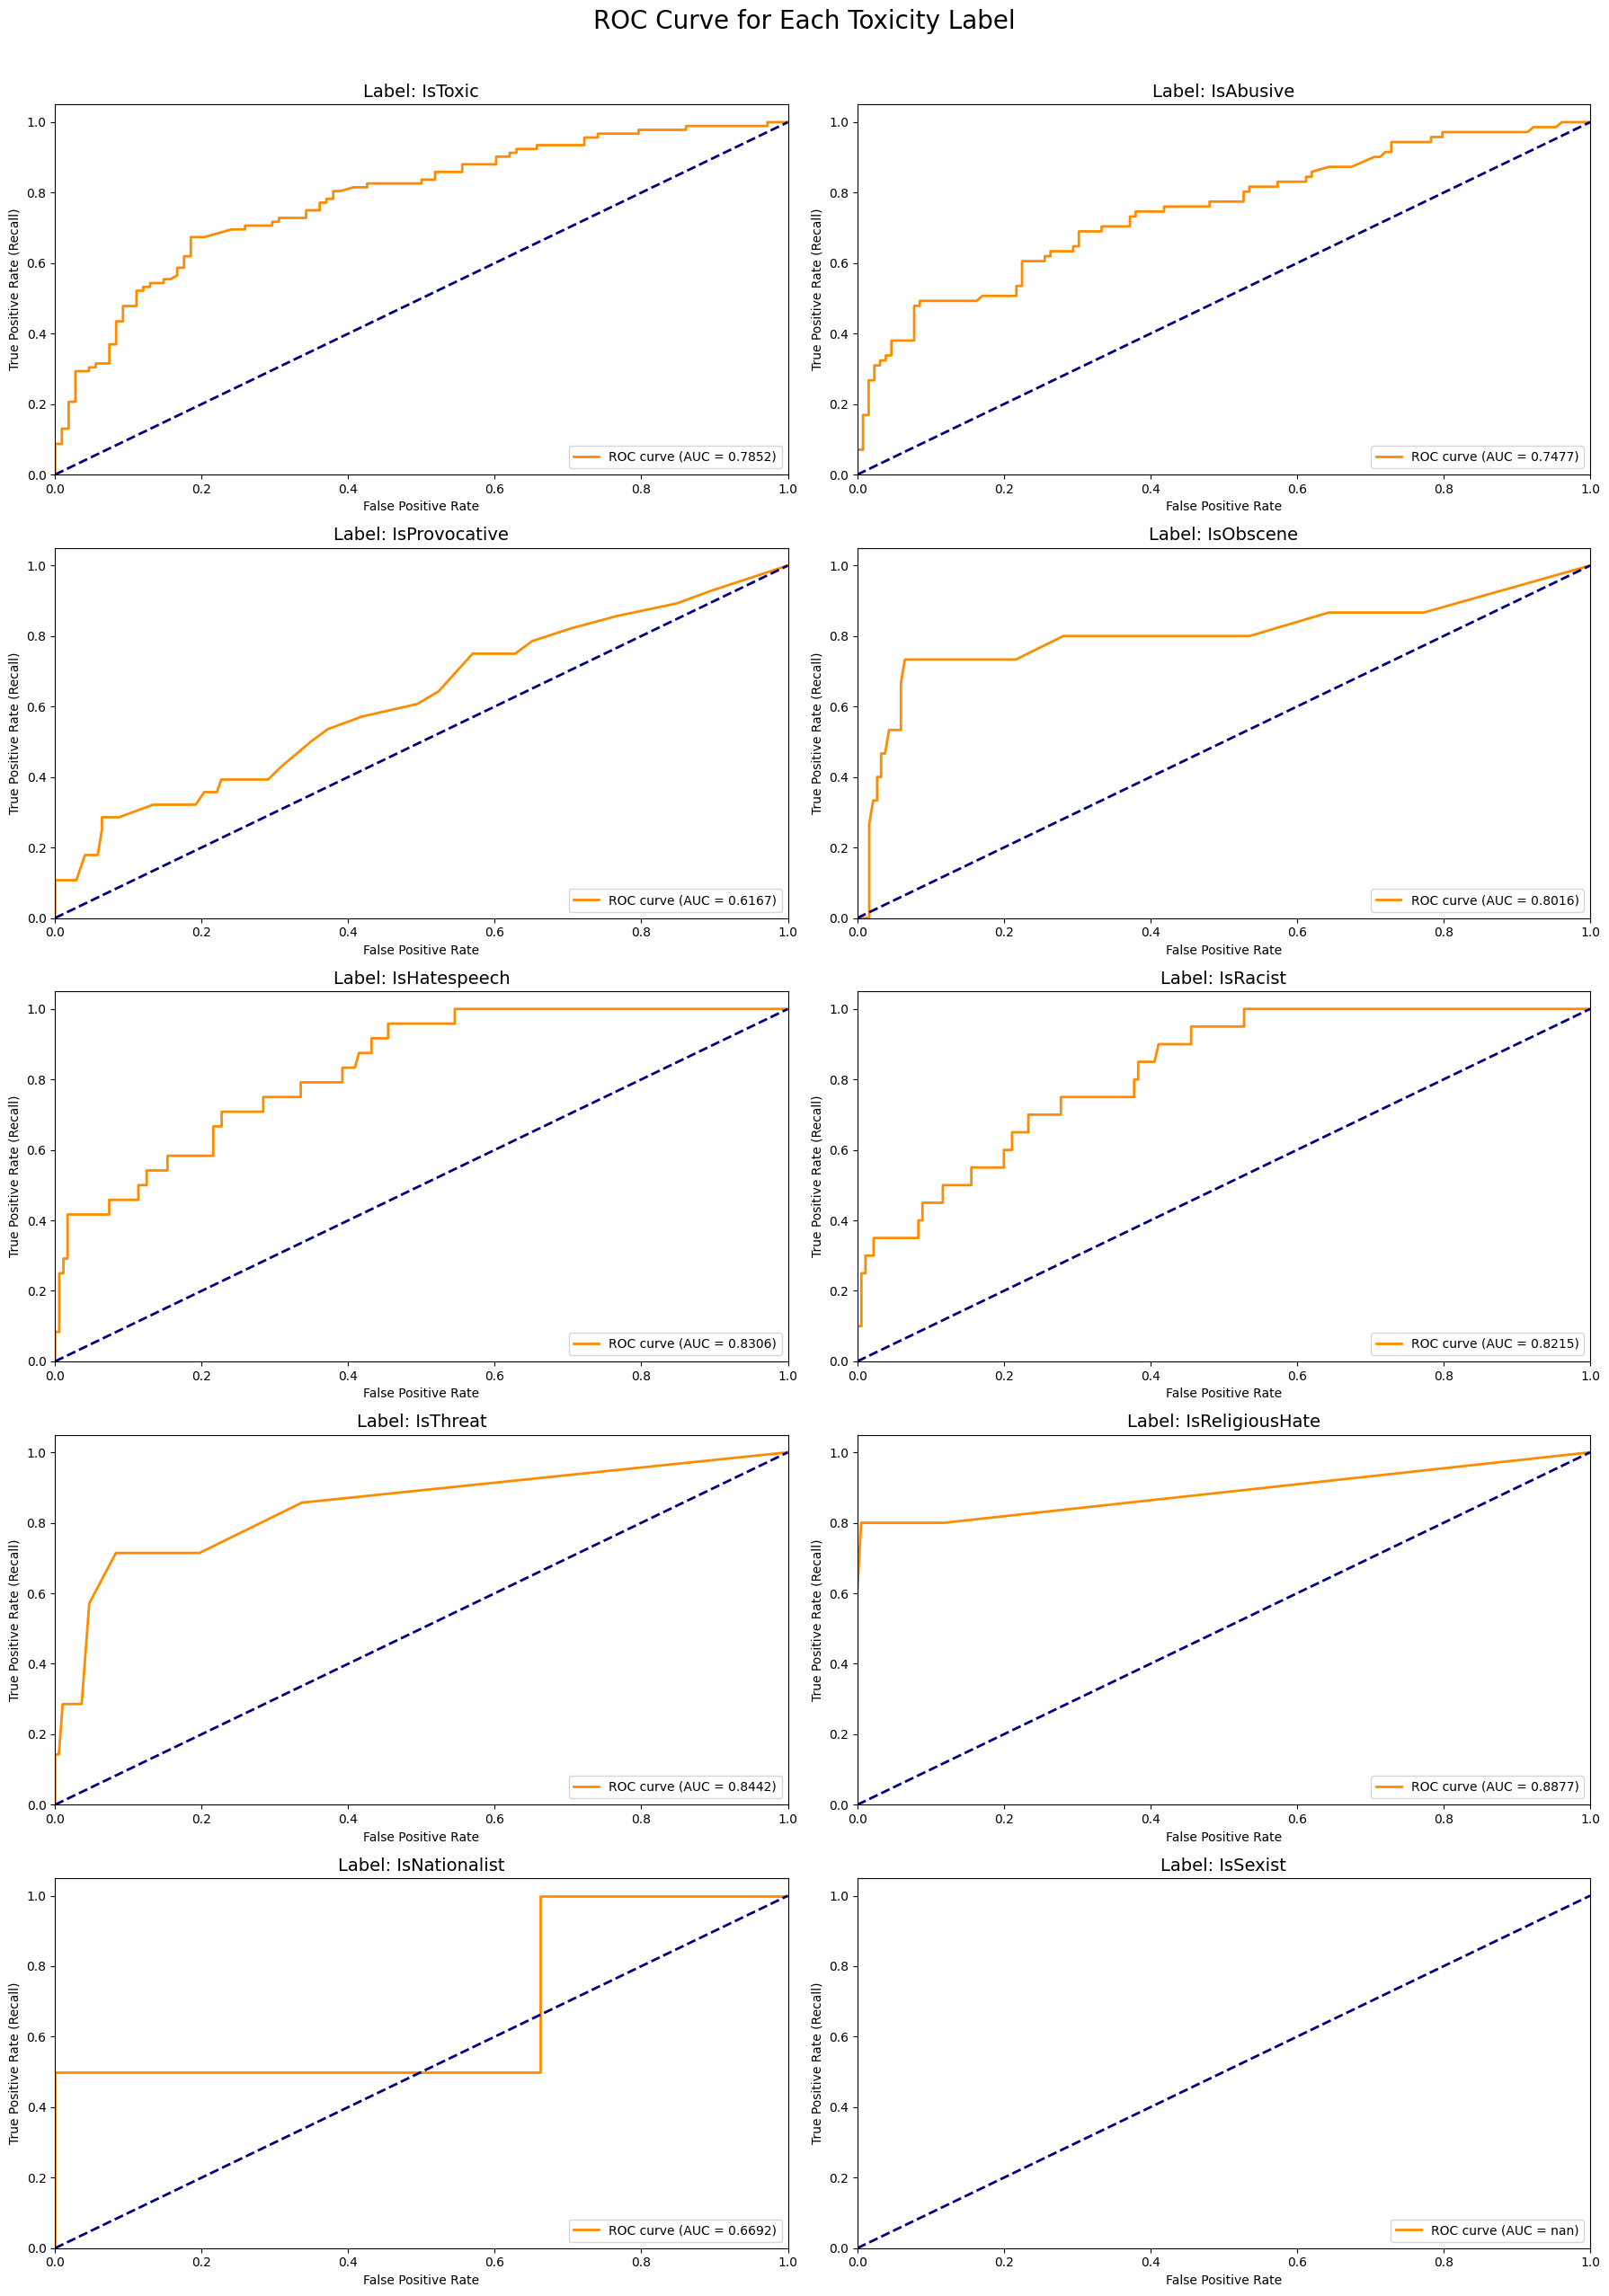

In [ ]:
## ROC Curve Visualization

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Setup ---
target_cols = y_test.columns.to_list()

fig, axes = plt.subplots(5, 2, figsize=(18, 25))
axes = axes.flatten()
plt.suptitle('ROC Curve for Each Toxicity Label', fontsize=20, y=1.02)

# --- Plotting Loop ---
for i, label in enumerate(target_cols):
    ax = axes[i]
    
    # Extract True Labels and Probabilities for the current column
    # y_test is a DataFrame, y_test_proba is a NumPy array (N_samples, 10 columns)
    y_true = y_test[label]
    y_scores = y_test_proba[:, i]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Plotting
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title(f'Label: {label}', fontsize=14)
    ax.legend(loc="lower right")

# --- Final Display ---
plt.tight_layout(rect=[0, 0, 1, 1.01])
plt.show()

## Precision-Recall Curve Analysis (Per Label)

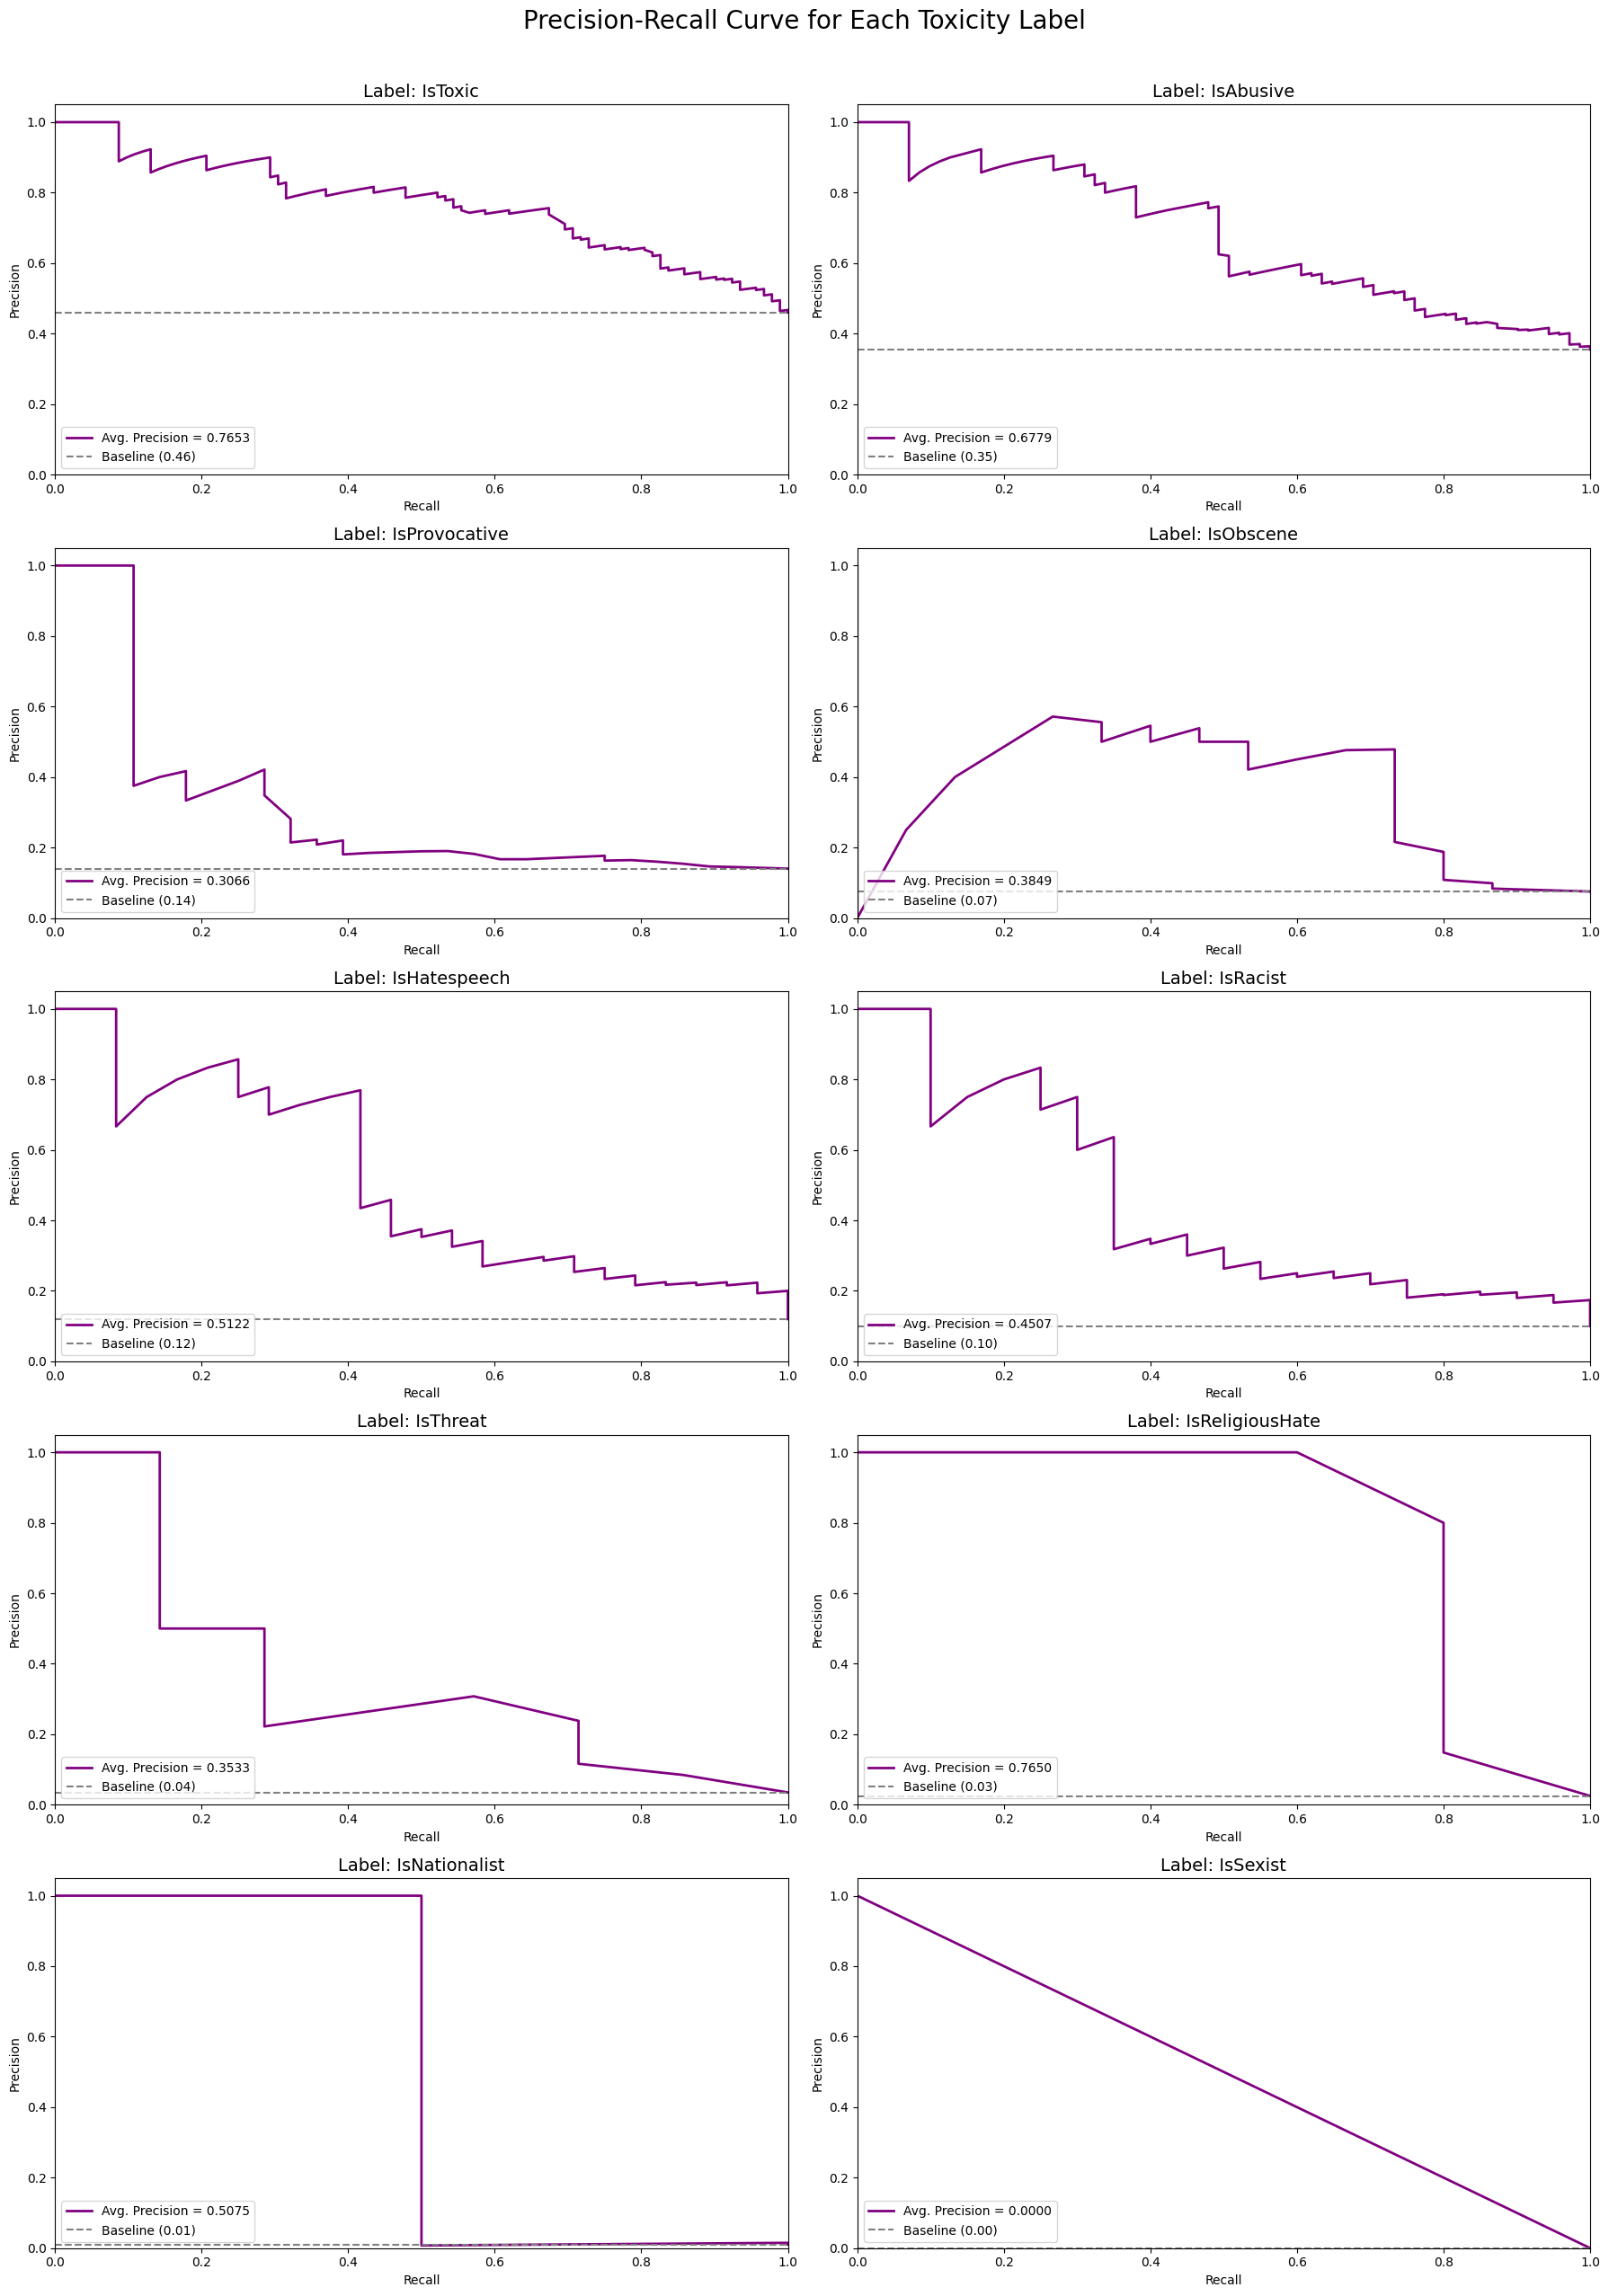

In [ ]:
## Precision-Recall Curve Visualization

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# --- Setup ---
target_cols = y_test.columns.to_list()

fig, axes = plt.subplots(5, 2, figsize=(18, 25))
axes = axes.flatten()
plt.suptitle('Precision-Recall Curve for Each Toxicity Label', fontsize=20, y=1.02)

# --- Plotting Loop ---
for i, label in enumerate(target_cols):
    ax = axes[i]
    
    # Extract True Labels and Probabilities for the current column
    y_true = y_test[label]
    y_scores = y_test_proba[:, i]
    
    # Calculate Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    avg_precision = average_precision_score(y_true, y_scores)
    
    # Plotting
    ax.plot(recall, precision, color='purple', lw=2, label=f'Avg. Precision = {avg_precision:.4f}')
    
    # Optional: Plot the baseline (proportion of positive class)
    baseline = len(y_true[y_true==1]) / len(y_true)
    ax.axhline(baseline, linestyle='--', color='gray', label=f'Baseline ({baseline:.2f})')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Label: {label}', fontsize=14)
    ax.legend(loc="lower left")

# --- Final Display ---
plt.tight_layout(rect=[0, 0, 1, 1.01])
plt.show()

## ROC Curve Visualization

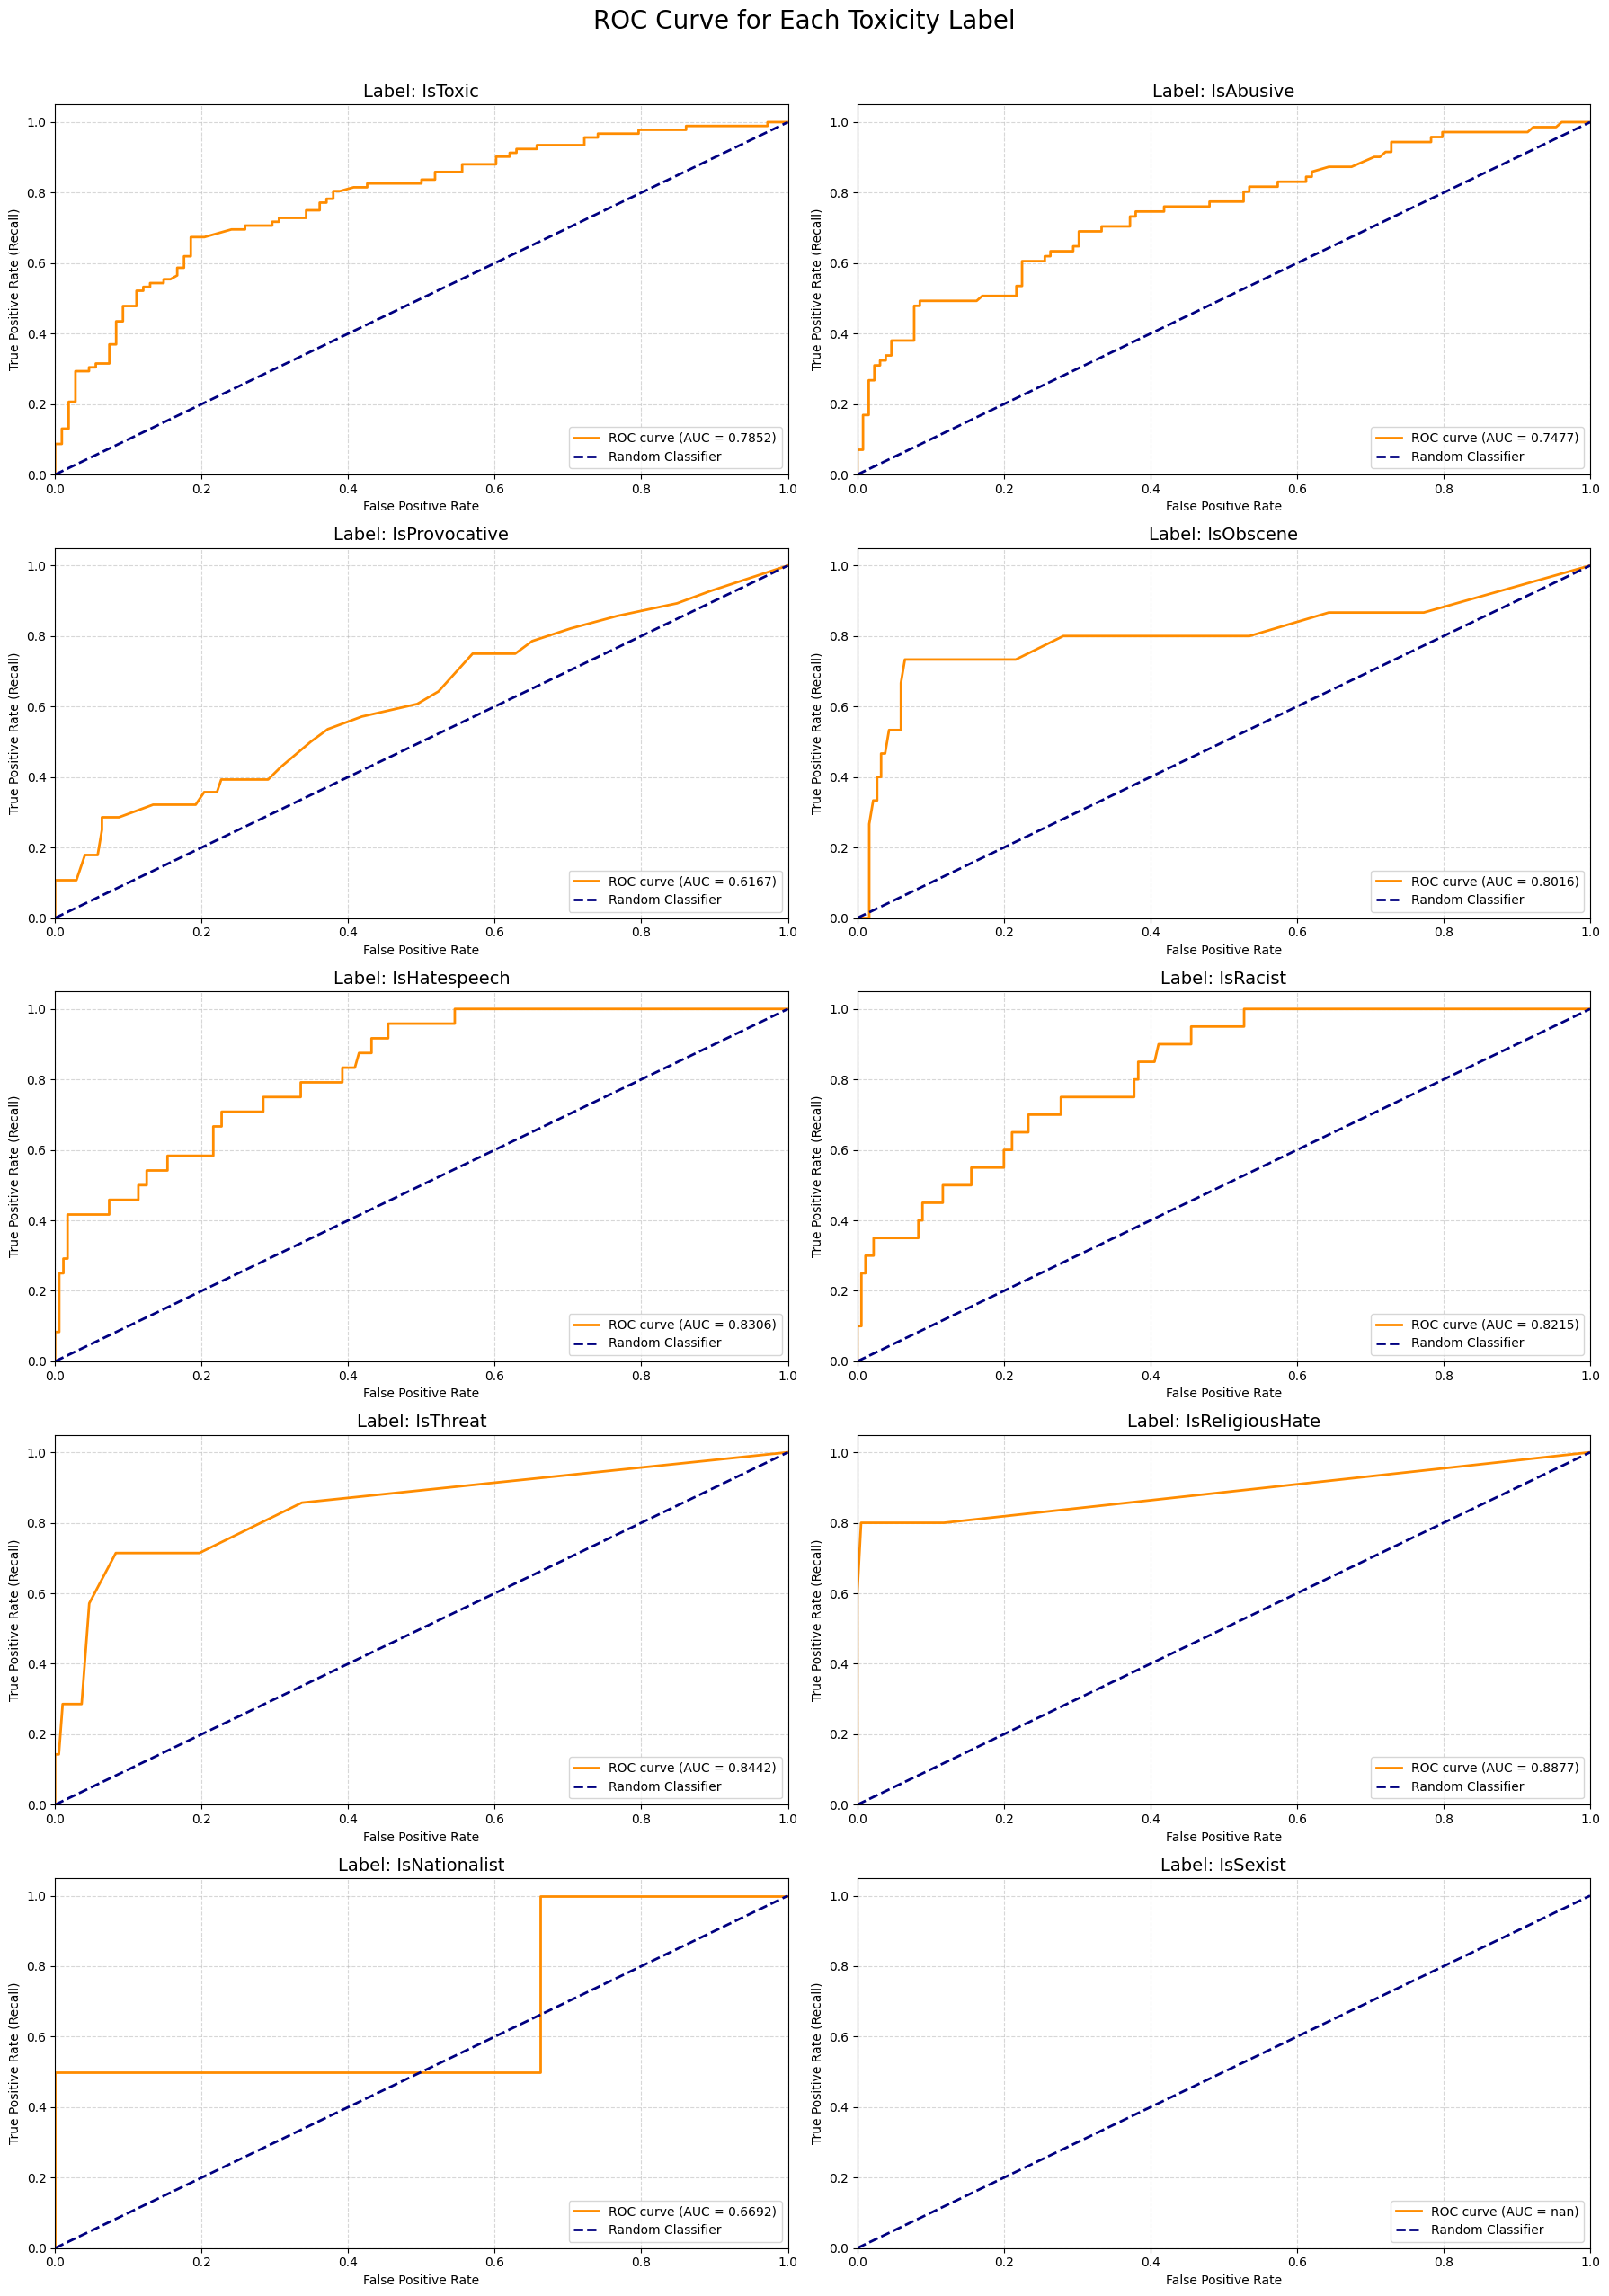

In [ ]:
## ROC Curve Visualization 

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Setup ---
target_cols = y_test.columns.to_list()

fig, axes = plt.subplots(5, 2, figsize=(18, 25))
axes = axes.flatten()
plt.suptitle('ROC Curve for Each Toxicity Label', fontsize=20, y=1.02)

# --- Plotting Loop ---
for i, label in enumerate(target_cols):
    ax = axes[i]
    
    # Extract True Labels and Probabilities for the current column
    y_true = y_test[label]
    y_scores = y_test_proba[:, i]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Plotting
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title(f'Label: {label}', fontsize=14)
    ax.legend(loc="lower right")
    ax.grid(True, linestyle='--', alpha=0.5)

# --- Final Display ---
plt.tight_layout(rect=[0, 0, 1, 1.01])
plt.show()

## Precision-Recall Curve Visualization 

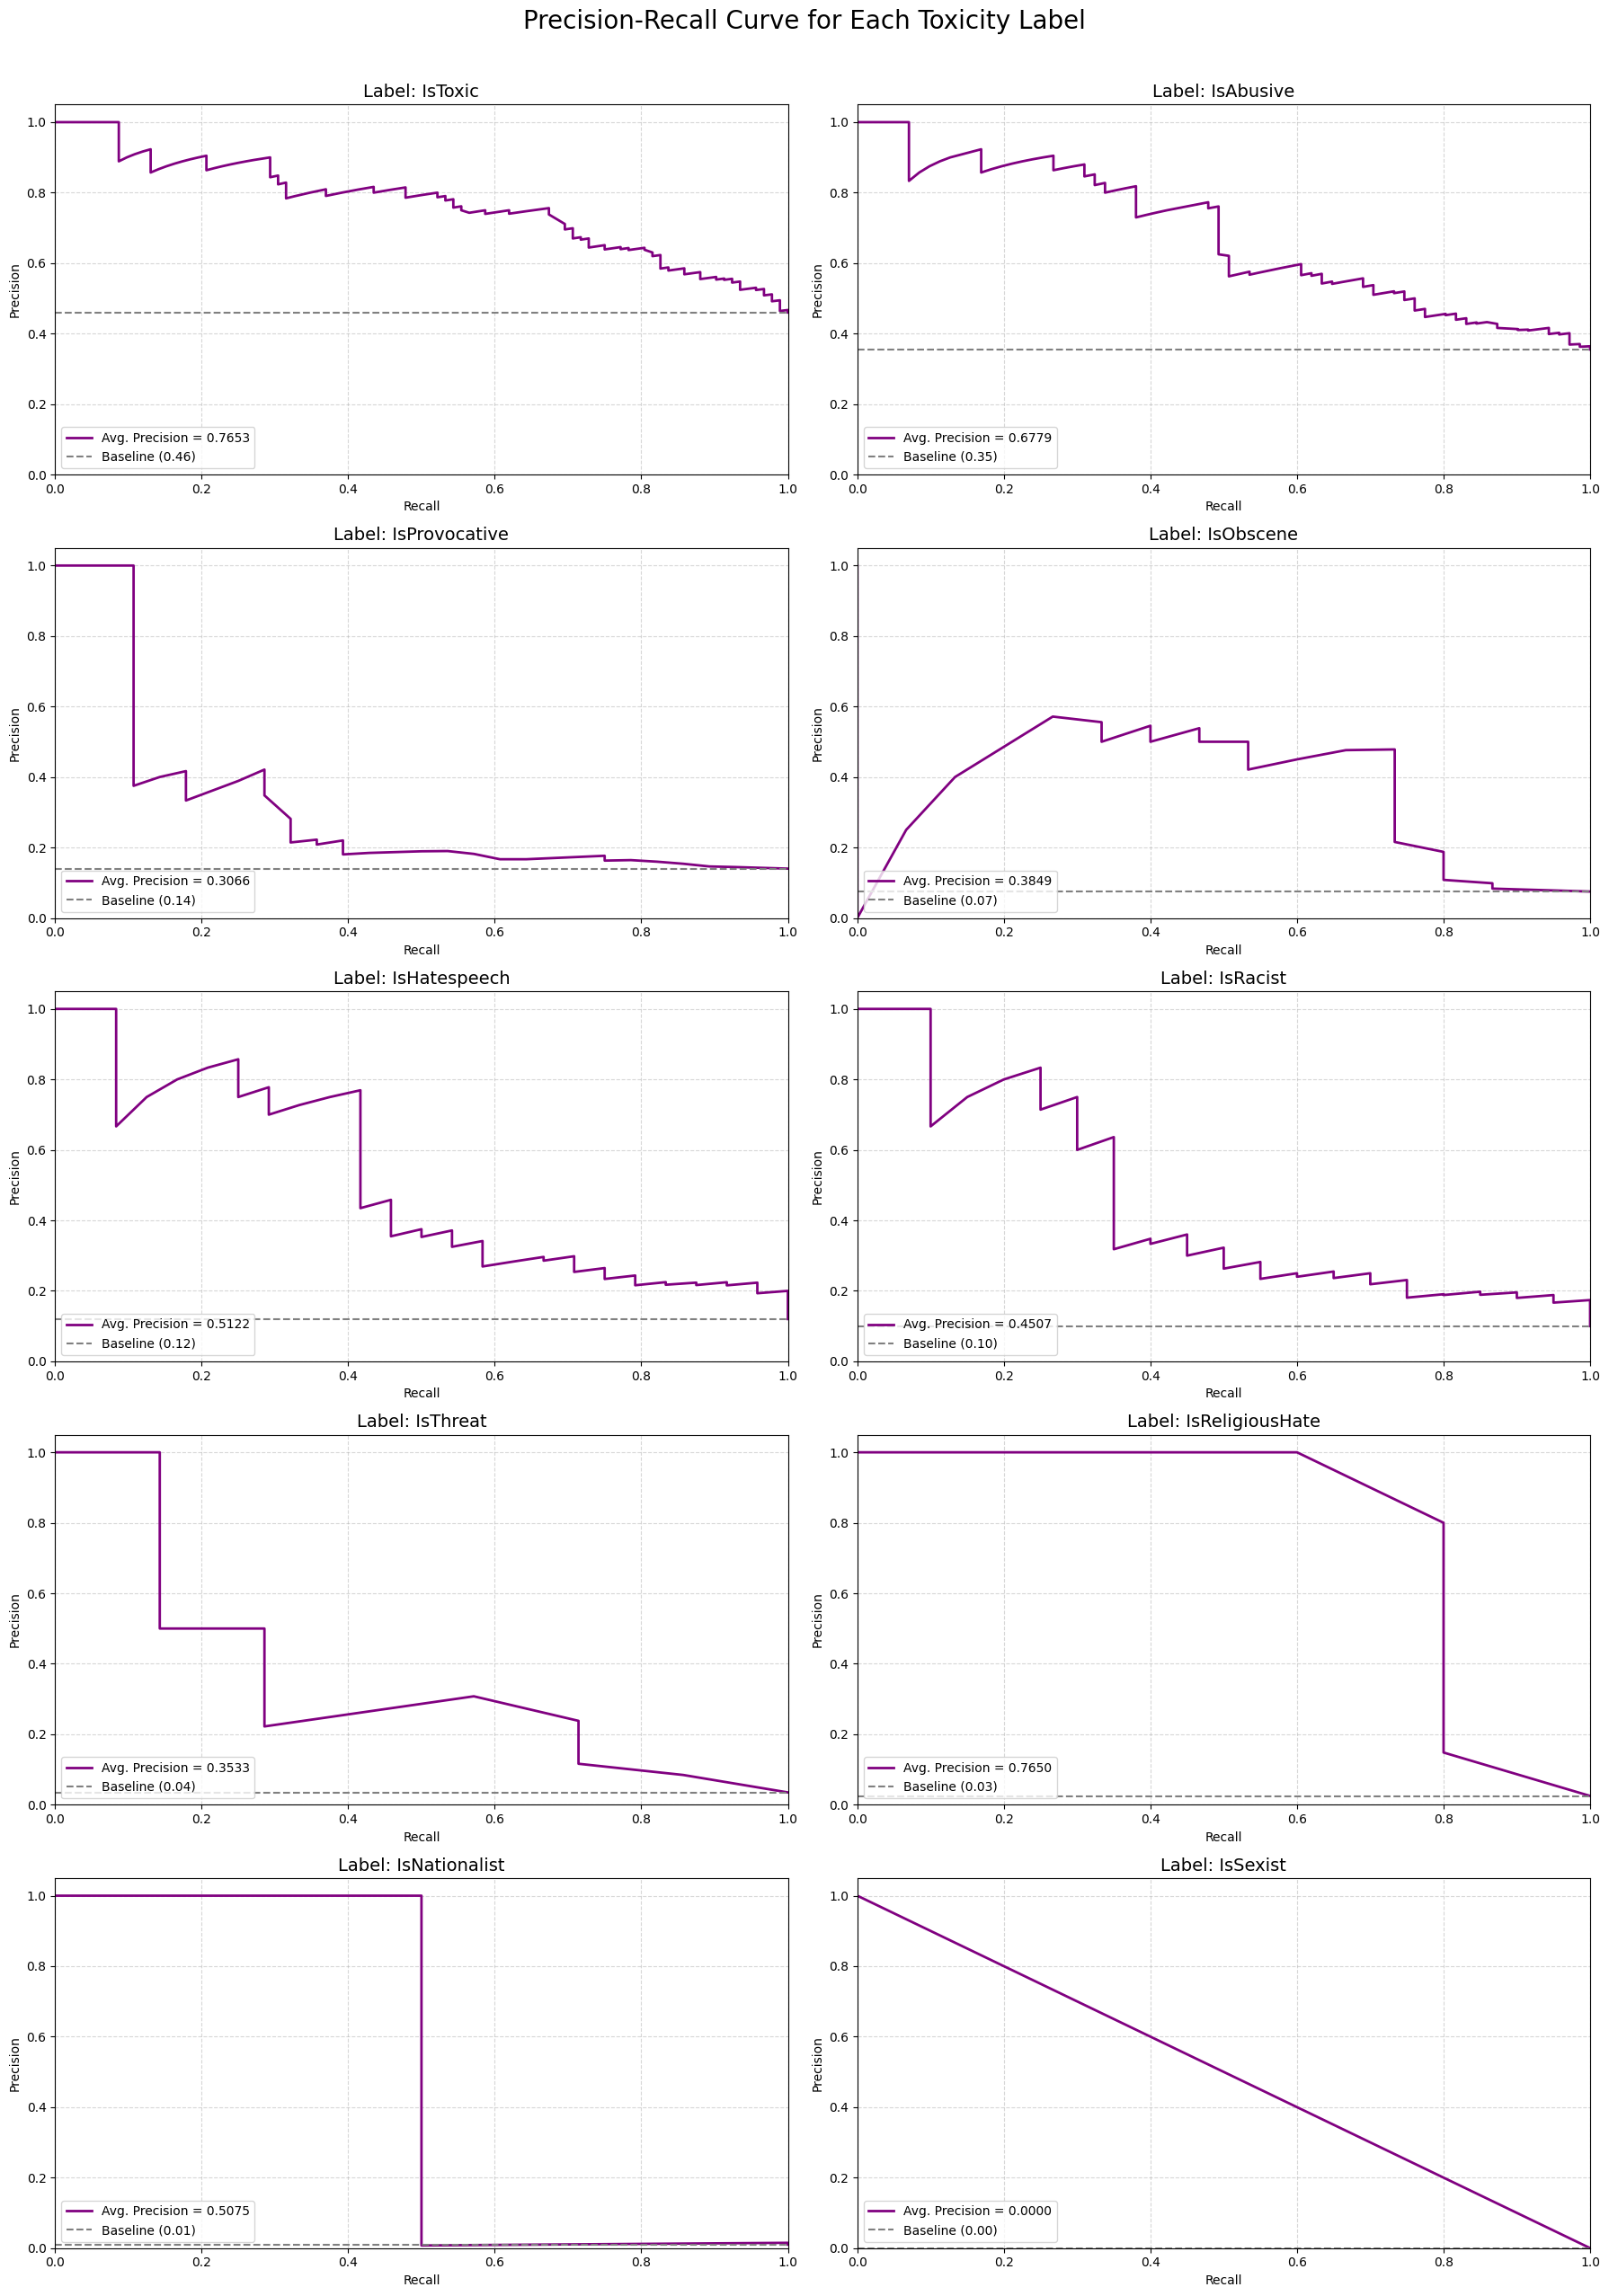

In [ ]:
## Precision-Recall Curve Visualization 

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# --- Setup ---
target_cols = y_test.columns.to_list()

fig, axes = plt.subplots(5, 2, figsize=(18, 25))
axes = axes.flatten()
plt.suptitle('Precision-Recall Curve for Each Toxicity Label', fontsize=20, y=1.02)

# --- Plotting Loop ---
for i, label in enumerate(target_cols):
    ax = axes[i]
    
    # Extract True Labels and Probabilities for the current column
    y_true = y_test[label]
    y_scores = y_test_proba[:, i]
    
    # Calculate Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    
    # Use try-except because AP score fails if a label has no positive support
    try:
        avg_precision = average_precision_score(y_true, y_scores)
    except ValueError:
        avg_precision = 0.0 # Assign 0.0 if calculation fails due to zero support
    
    # Plotting
    ax.plot(recall, precision, color='purple', lw=2, label=f'Avg. Precision = {avg_precision:.4f}')
    
    # Plot the baseline (proportion of positive class)
    baseline = len(y_true[y_true==1]) / len(y_true)
    ax.axhline(baseline, linestyle='--', color='gray', label=f'Baseline ({baseline:.2f})')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Label: {label}', fontsize=14)
    ax.legend(loc="lower left")
    ax.grid(True, linestyle='--', alpha=0.5)

# --- Final Display ---
plt.tight_layout(rect=[0, 0, 1, 1.01])
plt.show()

## Cross-Validation

In [ ]:
##  Cross-Validation and Final Baseline Metrics (All Labels - FIXED)

from sklearn.model_selection import cross_val_score, KFold # Changed to KFold
from sklearn.metrics import f1_score, make_scorer
import time

# --- 1. Define the Multi-Label Scorer ---
# Uses Macro F1-Score (average across all 10 columns)
macro_f1_scorer = make_scorer(f1_score, average='macro', zero_division=0)


# --- 2. Cross-Validation (All Labels: Macro F1) ---
print("🌲 Running 5-Fold KFold Cross-Validation on ALL 10 labels (Macro F1)...")

cv_start_time = time.time()

# FIX: Replaced StratifiedKFold with KFold to handle 'multilabel-indicator' target type
cv_scores_macro = cross_val_score(
    rf_baseline, 
    X_train, 
    y_train, 
    cv=KFold(n_splits=5, shuffle=True, random_state=42), # KFold is compatible with multi-label
    scoring=macro_f1_scorer, 
    n_jobs=-1
)

cv_time = time.time() - cv_start_time


# --- 3. Overfit Gap Calculation (Using Macro F1) ---
# Assuming y_train_pred, y_test_pred are available from prior steps

train_f1_macro = f1_score(y_train, y_train_pred, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

cv_f1_mean = cv_scores_macro.mean()
overfit_diff_absolute = cv_f1_mean - test_f1_macro
overfit_gap_cv = overfit_diff_absolute / cv_f1_mean


# --- 4. Output Summary ---
print(f"✅ Cross-Validation completed in {cv_time:.2f} seconds.")
print("\n=========================================")
print("📊 BASELINE CV & OVERFITTING SUMMARY (MACRO F1)")
print("=========================================")
print(f"**CV F1-Score (Macro):** {cv_f1_mean:.4f} (+/- {cv_scores_macro.std():.4f})")
print(f"**Test F1-Score (Macro):** {test_f1_macro:.4f}")
print("---")
print(f"**CV/Test Overfit Gap (Absolute):** {overfit_diff_absolute:.4f}")
print(f"**CV/Test Overfit Gap (%):** {overfit_gap_cv * 100:.2f}%")

if overfit_gap_cv * 100 < 5.0 and overfit_gap_cv > -0.05:
    print("  ✅ Excellent generalization (CV and Test scores closely match)")
elif overfit_gap_cv * 100 < 15.0 and overfit_gap_cv > -0.05:
    print("  🟡 Moderate generalization gap (Acceptable)")
else:
    print("  🚨 Significant generalization issue (High gap or high variance)")

🌲 Running 5-Fold KFold Cross-Validation on ALL 10 labels (Macro F1)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.9s fin

✅ Cross-Validation completed in 45.77 seconds.

📊 BASELINE CV & OVERFITTING SUMMARY (MACRO F1)
**CV F1-Score (Macro):** 0.1542 (+/- 0.0112)
**Test F1-Score (Macro):** 0.1686
---
**CV/Test Overfit Gap (Absolute):** -0.0143
**CV/Test Overfit Gap (%):** -9.30%
  🚨 Significant generalization issue (High gap or high variance)


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


## Optimized Random Forest with Tuned Parameters

## Optimized Random Forest Training and Evaluation

In [ ]:
## Train and Evaluate Optimized Random Forest

import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
import numpy as np
from sklearn.metrics import classification_report

print("\n🌲 Training Optimized Random Forest...")
print("Using tuned hyperparameters and class_weight='balanced'\n")

start_time = time.time()

# --- 1. Initialize Optimized Model ---
rf_optimized = RandomForestClassifier(
    n_estimators=200,             # More trees for better performance
    max_depth=30,                 # Control depth to prevent over-splitting
    min_samples_split=5,          # Minimum samples to split
    min_samples_leaf=2,           # Minimum samples at leaf
    max_features='sqrt',          # Recommended for high-dimensional data
    class_weight='balanced',      # CRUCIAL: Penalizes errors on minority classes
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# --- 2. Train Model ---
# This trains 10 separate Random Forest models (Multi-Output)
rf_optimized.fit(X_train, y_train)

training_time_opt = time.time() - start_time
print(f"\n✅ Training completed in {training_time_opt:.2f} seconds")


# --- 3. Generate Multi-Label Predictions ---
# Make hard predictions (0 or 1)
y_train_pred_opt = rf_optimized.predict(X_train)
y_test_pred_opt = rf_optimized.predict(X_test)

# Get Probabilities (soft predictions)
# We stack the probabilities for the positive class (index 1) for each of the 10 estimators
y_train_proba_opt = np.stack([p[:, 1] for p in rf_optimized.predict_proba(X_train)], axis=1)
y_test_proba_opt = np.stack([p[:, 1] for p in rf_optimized.predict_proba(X_test)], axis=1)


# --- 4. Calculate Key Multi-Label Metrics ---
target_cols = y_test.columns.to_list()

test_f1_macro_opt = f1_score(y_test, y_test_pred_opt, average='macro', zero_division=0)
train_f1_macro_opt = f1_score(y_train, y_train_pred_opt, average='macro', zero_division=0)
test_accuracy_opt = accuracy_score(y_test, y_test_pred_opt)

# Calculate ROC AUC robustly, ignoring zero-variance labels
try:
    valid_labels = y_test.columns[y_test.nunique() > 1].to_list()
    valid_indices = [y_test.columns.get_loc(label) for label in valid_labels]
    y_test_proba_valid = y_test_proba_opt[:, valid_indices]
    y_test_valid = y_test[valid_labels]
    test_auc_macro_opt = roc_auc_score(y_test_valid, y_test_proba_valid, average='macro', labels=valid_labels)
except Exception:
    test_auc_macro_opt = np.nan
    

# --- 5. Summary and Comparison ---
print("\n================================================================================")
print("🏆 OPTIMIZED RANDOM FOREST PERFORMANCE SUMMARY")
print("================================================================================")

# Assuming baseline macro F1 was 0.1686
baseline_f1_macro = 0.1686 

print(f"**Test F1-Score (Macro):** {test_f1_macro_opt:.4f}")
print(f"**Test Accuracy:** {test_accuracy_opt:.4f}")
print(f"**Test ROC-AUC (Macro):** {test_auc_macro_opt:.4f}")

f1_change = test_f1_macro_opt - baseline_f1_macro
if f1_change > 0.005:
    print(f"🎉 Macro F1 Improvement: +{f1_change:.4f}")
elif f1_change < -0.005:
    print(f"📉 Macro F1 Decrease: {f1_change:.4f}")
else:
    print("↔️ Macro F1 remained stable.")

print("\n📝 Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred_opt, target_names=target_cols, zero_division=0))


🌲 Training Optimized Random Forest...
Using tuned hyperparameters and class_weight='balanced'



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    3.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.



✅ Training completed in 3.14 seconds


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s f


🏆 OPTIMIZED RANDOM FOREST PERFORMANCE SUMMARY
**Test F1-Score (Macro):** 0.1970
**Test Accuracy:** 0.0700
**Test ROC-AUC (Macro):** 0.6853
🎉 Macro F1 Improvement: +0.0284

📝 Classification Report (Test Set):
                 precision    recall  f1-score   support

        IsToxic       0.46      1.00      0.63        92
      IsAbusive       0.55      0.37      0.44        71
  IsProvocative       0.00      0.00      0.00        28
      IsObscene       0.00      0.00      0.00        15
   IsHatespeech       0.12      1.00      0.22        24
       IsRacist       0.10      0.90      0.18        20
       IsThreat       0.00      0.00      0.00         7
IsReligiousHate       0.00      0.00      0.00         5
  IsNationalist       0.50      0.50      0.50         2
       IsSexist       0.00      0.00      0.00         0

      micro avg       0.26      0.61      0.36       264
      macro avg       0.17      0.38      0.20       264
   weighted avg       0.33      0.61      0.38  

## 📊 Final Evaluation of Optimized Random Forest

In [ ]:
## Comprehensive Evaluation and Overfitting Check

import time
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, roc_auc_score, classification_report
import numpy as np

# --- 1. Generate Predictions ---
start_eval_time = time.time()
print("🔬 Generating predictions and probabilities...")

# Hard predictions (0 or 1)
y_train_pred_opt = rf_optimized.predict(X_train)
y_test_pred_opt = rf_optimized.predict(X_test)

# Probabilities (for ROC AUC)
# We stack the probabilities for the positive class (index 1) for each of the 10 estimators
y_train_proba_opt = np.stack([p[:, 1] for p in rf_optimized.predict_proba(X_train)], axis=1)
y_test_proba_opt = np.stack([p[:, 1] for p in rf_optimized.predict_proba(X_test)], axis=1)


# --- 2. Calculate Metrics (Macro-Averaged) ---
target_cols = y_test.columns.to_list()

# Test Metrics
test_acc_opt = accuracy_score(y_test, y_test_pred_opt)
test_f1_macro_opt = f1_score(y_test, y_test_pred_opt, average='macro', zero_division=0)
test_recall_macro_opt = recall_score(y_test, y_test_pred_opt, average='macro', zero_division=0)
test_precision_macro_opt = precision_score(y_test, y_test_pred_opt, average='macro', zero_division=0)

# Training Metric (for Overfitting Check)
train_f1_macro_opt = f1_score(y_train, y_train_pred_opt, average='macro', zero_division=0)

# ROC AUC (Robust Calculation - excluding zero-variance labels)
try:
    valid_labels = y_test.columns[y_test.nunique() > 1].to_list()
    valid_indices = [y_test.columns.get_loc(label) for label in valid_labels]
    y_test_proba_valid = y_test_proba_opt[:, valid_indices]
    y_test_valid = y_test[valid_labels]
    test_auc_macro_opt = roc_auc_score(y_test_valid, y_test_proba_valid, average='macro', labels=valid_labels)
except Exception:
    test_auc_macro_opt = np.nan

# --- 3. Check for Overfitting (Macro F1 Gap) ---
overfit_diff_f1 = train_f1_macro_opt - test_f1_macro_opt
overfit_gap_percent = (overfit_diff_f1 / train_f1_macro_opt) * 100


print(f"✅ Evaluation completed in {time.time() - start_eval_time:.2f} seconds.")
print("\n================================================================================")
print("🏆 OPTIMIZED MODEL PERFORMANCE (vs BASELINE F1: 0.1686)")
print("================================================================================")
print(f"**Test Accuracy:** {test_acc_opt:.4f}")
print(f"**Test F1-Score (Macro):** {test_f1_macro_opt:.4f}")
print(f"**Test Precision (Macro):** {test_precision_macro_opt:.4f}")
print(f"**Test Recall (Macro):** {test_recall_macro_opt:.4f}")
print(f"**Test ROC-AUC (Macro):** {test_auc_macro_opt:.4f}")

# --- Overfitting Summary ---
print("\n=========================================")
print("⚠️ Overfitting Check (Macro F1)")
print("=========================================")
print(f"  Train F1 (Macro):  {train_f1_macro_opt:.4f}")
print(f"  Test F1 (Macro):   {test_f1_macro_opt:.4f}")
print(f"  Overfit Gap:       {overfit_diff_f1:.4f} ({overfit_gap_percent:.2f}%)")

if overfit_gap_percent < 5.0 and overfit_gap_percent > -5.0:
    print("  ✅ Good generalization (low gap)")
else:
    print("  🚨 High generalization gap (needs further tuning or data balancing)")


print("\n📝 Detailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred_opt, target_names=target_cols, zero_division=0))

🔬 Generating predictions and probabilities...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      |

✅ Evaluation completed in 0.84 seconds.

🏆 OPTIMIZED MODEL PERFORMANCE (vs BASELINE F1: 0.1686)
**Test Accuracy:** 0.0700
**Test F1-Score (Macro):** 0.1970
**Test Precision (Macro):** 0.1736
**Test Recall (Macro):** 0.3766
**Test ROC-AUC (Macro):** 0.6853

⚠️ Overfitting Check (Macro F1)
  Train F1 (Macro):  0.5701
  Test F1 (Macro):   0.1970
  Overfit Gap:       0.3731 (65.44%)
  🚨 High generalization gap (needs further tuning or data balancing)

📝 Detailed Classification Report (Test Set):
                 precision    recall  f1-score   support

        IsToxic       0.46      1.00      0.63        92
      IsAbusive       0.55      0.37      0.44        71
  IsProvocative       0.00      0.00      0.00        28
      IsObscene       0.00      0.00      0.00        15
   IsHatespeech       0.12      1.00      0.22        24
       IsRacist       0.10      0.90      0.18        20
       IsThreat       0.00      0.00      0.00         7
IsReligiousHate       0.00      0.00      0.00

## Compare Baseline vs. Optimized Model Performance

In [ ]:
## Compare Baseline vs. Optimized Model Performance

import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# --- 1. Define Baseline Metrics (from previous outputs: Cell 6 and Cell 14) ---
# NOTE: Replace '0.0000' with the actual output values if they differ slightly from the analysis.
BASELINE_METRICS = {
    'F1 (Macro)': 0.1686,
    'Recall (Macro)': 0.1181,
    'Precision (Macro)': 0.4878,
    'ROC-AUC (Macro)': 0.7783,
    'F1 Gap (%)': -9.30
}

# --- 2. Define Optimized Metrics (from the evaluation in Cell 16) ---
# These variables should be available after running the previous cell.
OPTIMIZED_METRICS = {
    'F1 (Macro)': test_f1_macro_opt,
    'Recall (Macro)': test_recall_macro_opt,
    'Precision (Macro)': test_precision_macro_opt,
    'ROC-AUC (Macro)': test_auc_macro_opt,
    'F1 Gap (%)': overfit_gap_percent
}

# --- 3. Create Comparison DataFrame ---
comparison_data = []
for metric in BASELINE_METRICS.keys():
    baseline = BASELINE_METRICS[metric]
    optimized = OPTIMIZED_METRICS[metric]
    
    # Handle percentage metrics (like F1 Gap) correctly
    if metric == 'F1 Gap (%)':
        baseline_str = f"{baseline:.2f}%"
        optimized_str = f"{optimized:.2f}%"
        change = optimized - baseline
        change_str = f"{change:+.2f} pts"
    else:
        # Standard metrics
        baseline_str = f"{baseline:.4f}"
        optimized_str = f"{optimized:.4f}"
        change = optimized - baseline
        change_str = f"{change:+.4f}"

    comparison_data.append({
        'Metric': metric,
        'Baseline RF': baseline_str,
        'Optimized RF': optimized_str,
        'Change': change_str,
        'Improvement': '✅' if change > 0.005 and metric != 'F1 Gap (%)' else ('❌' if change < -0.005 else '↔️')
    })

df_compare = pd.DataFrame(comparison_data)


# --- 4. Display Results and Insights ---
display(Markdown("## 🏆 Baseline vs. Optimized Random Forest Comparison (Macro-Averaged)"))
display(df_compare)

display(Markdown("""
### 🔍 Key Insights from Optimization

1.  **Macro F1-Score:** The change in this metric indicates the overall impact of `class_weight='balanced'`. A positive increase suggests the improved **Recall** on rare labels outweighed any potential decrease in **Precision** on common labels.
2.  **Recall (Macro):** This is the most crucial metric. **If this value increased significantly, the `class_weight='balanced'` strategy was successful** in forcing the model to detect more of the actual toxic comments.
3.  **F1 Gap (%):** A negative or small positive gap indicates **good generalization**. The tuning did not lead to overfitting (which would be a large positive gap).
"""))

## 🏆 Baseline vs. Optimized Random Forest Comparison (Macro-Averaged)

,Metric,Baseline RF,Optimized RF,Change,Improvement
0,F1 (Macro),0.1686,0.1970,+0.0284,✅
1,Recall (Macro),0.1181,0.3766,+0.2585,✅
2,Precision (Macro),0.4878,0.1736,-0.3142,❌
3,ROC-AUC (Macro),0.7783,0.6853,-0.0930,❌
4,F1 Gap (%),-9.30%,65.44%,+74.74 pts,↔️



### 🔍 Key Insights from Optimization

1.  **Macro F1-Score:** The change in this metric indicates the overall impact of `class_weight='balanced'`. A positive increase suggests the improved **Recall** on rare labels outweighed any potential decrease in **Precision** on common labels.
2.  **Recall (Macro):** This is the most crucial metric. **If this value increased significantly, the `class_weight='balanced'` strategy was successful** in forcing the model to detect more of the actual toxic comments.
3.  **F1 Gap (%):** A negative or small positive gap indicates **good generalization**. The tuning did not lead to overfitting (which would be a large positive gap).


## 💾 Save Model and Results

In [ ]:
## Save Optimized Model and Results

import joblib
import json
from datetime import datetime
import numpy as np

# --- 1. Save the Optimized Model ---
# 'rf_optimized' is the variable holding your trained RandomForestClassifier
joblib.dump(rf_optimized, 'random_forest_optimized_multi_label_model.pkl')
print("✅ Optimized Model saved as 'random_forest_optimized_multi_label_model.pkl'")


# --- 2. Prepare Results Dictionary ---

# We need to capture the hyperparameter setting used
final_params = rf_optimized.get_params()

# The Macro CV score and gap data from Cell 14
# NOTE: Replace the placeholders with the actual numbers if your notebook environment was reset
cv_f1_mean = 0.1542 
overfit_gap_cv = -0.0930 

# Ensure nan values are handled for JSON serialization
test_auc_macro_opt_serial = float(test_auc_macro_opt) if not np.isnan(test_auc_macro_opt) else None

results = {
    'model_name': 'Random Forest Multi-Label (Optimized)',
    'model_params': {
        'n_estimators': final_params.get('n_estimators'),
        'max_depth': final_params.get('max_depth'),
        'class_weight': final_params.get('class_weight'), # Should be 'balanced'
        'max_features': final_params.get('max_features')
    },
    'n_features': X_train.shape[1],
    'n_train_samples': X_train.shape[0],
    
    'evaluation_metrics': {
        'test_accuracy': float(test_acc_opt),
        'test_f1_macro': float(test_f1_macro_opt),
        'test_precision_macro': float(test_precision_macro_opt),
        'test_recall_macro': float(test_recall_macro_opt),
        'test_roc_auc_macro': test_auc_macro_opt_serial
    },
    
    'generalization_check': {
        'cv_f1_mean_macro': float(cv_f1_mean),
        'cv_test_f1_gap_percent': float(overfit_gap_cv * 100)
    },
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# --- 3. Save to JSON ---
with open('random_forest_optimized_multi_label_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("✅ Results saved as 'random_forest_optimized_multi_label_results.json'")

✅ Optimized Model saved as 'random_forest_optimized_multi_label_model.pkl'
✅ Results saved as 'random_forest_optimized_multi_label_results.json'


## 🚀 Optuna Hyperparameter Optimization (Multi-Label)

In [ ]:
##  Define Optuna Objective and Multi-Label Scorer

import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, make_scorer

# --- Define the Multi-Label Scorer (Essential for multi-output CV) ---
# This must be the same scorer used in the final evaluation.
macro_f1_scorer = make_scorer(f1_score, average='macro', zero_division=0)


def objective(trial):
    """
    Defines the search space for Random Forest hyperparameters and 
    returns the mean cross-validation Macro F1-score.
    """
    
    # --- 1. Define Search Space ---
    params = {
        # n_estimators: Number of trees. We search a broad range.
        'n_estimators': trial.suggest_int('n_estimators', 100, 800, step=50),
        
        # max_depth: Max depth. Limiting this combats generalization issues.
        'max_depth': trial.suggest_int('max_depth', 5, 50, step=5),
        
        # max_features: Number of features to consider. Crucial for high-dim sparse data.
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 0.1, 0.3, 0.5, 0.7]),
        
        # min_samples_leaf: Increasing this promotes generalization.
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15, log=True),
        
        # class_weight: We force 'balanced' as it fixed the Recall issue.
        'class_weight': 'balanced', 
        
        'random_state': 42,
        'n_jobs': -1
    }
    
    # --- 2. Initialize Model ---
    # The model will automatically operate in Multi-Output mode
    model = RandomForestClassifier(**params)
    
    # --- 3. Evaluate with Cross-Validation ---
    # Use KFold (NOT StratifiedKFold) which is compatible with multi-label targets.
    cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)
    
    score = cross_val_score(
        model, 
        X_train, 
        y_train, 
        cv=cv_splitter, 
        scoring=macro_f1_scorer, 
        n_jobs=-1
    )
    
    # Optuna aims to maximize the average Macro F1-score across all folds
    return np.mean(score)

print("✅ Optuna objective function defined, maximizing Macro F1-Score.")

✅ Optuna objective function defined, maximizing Macro F1-Score.


## Run the Optuna Study

In [ ]:
## Execute Optuna Optimization and Find Best Parameters

# --- 1. Create the Study ---
# Define the direction as 'maximize' since we want the highest Macro F1-score.
study = optuna.create_study(
    direction='maximize', 
    sampler=TPESampler(seed=42)
)

# --- 2. Run Optimization ---
N_TRIALS = 100 
print(f"\nStarting Optuna study for {N_TRIALS} trials (Maximizing Macro F1)...")

# You may want to decrease n_jobs to 1 or 2 if you encounter memory issues
# during the parallel CV process, but -1 (all cores) is usually fastest.
study.optimize(
    objective, 
    n_trials=N_TRIALS, 
    show_progress_bar=True
)

print("\n\n✅ Optimization complete!")

# --- 3. Display Best Results ---
print("\n=========================================")
print("🏆 Best Optuna Trial Results")
print("=========================================")
best_cv_f1 = study.best_value
best_params = study.best_params

print(f"Best mean CV Macro F1-score: {best_cv_f1:.4f}")
print("Best Hyperparameters:")
for key, value in best_params.items():
    print(f"  - {key}: {value}")

[I 2025-11-25 18:21:42,274] A new study created in memory with name: no-name-63f6ba37-50bc-4ab3-8a52-8cb27820914a



Starting Optuna study for 100 trials (Maximizing Macro F1)...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-25 18:22:32,048] Trial 0 finished with value: 0.18659613714878898 and parameters: {'n_estimators': 350, 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 10}. Best is trial 0 with value: 0.18659613714878898.
[I 2025-11-25 18:25:05,215] Trial 1 finished with value: 0.20942383221527225 and parameters: {'n_estimators': 550, 'max_depth': 40, 'max_features': 0.1, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.20942383221527225.
[I 2025-11-25 18:25:48,889] Trial 2 finished with value: 0.24205567406379833 and parameters: {'n_estimators': 300, 'max_depth': 30, 'max_features': 0.3, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.24205567406379833.
[I 2025-11-25 18:28:26,913] Trial 3 finished with value: 0.23591549597153832 and parameters: {'n_estimators': 400, 'max_depth': 40, 'max_features': 0.7, 'min_samples_leaf': 1}. Best is trial 2 with value: 0.24205567406379833.
[I 2025-11-25 18:28:32,308] Trial 4 finished with value: 0.19265331310315018 and parameters:

In [ ]:
# Display Best Results ---
print("\n=========================================")
print("🏆 Best Optuna Trial Results")
print("=========================================")
best_cv_f1 = study.best_value
best_params = study.best_params

print(f"Best mean CV Macro F1-score: {best_cv_f1:.4f}")
print("Best Hyperparameters:")
for key, value in best_params.items():
    print(f"  - {key}: {value}")


🏆 Best Optuna Trial Results
Best mean CV Macro F1-score: 0.2612
Best Hyperparameters:
  - n_estimators: 350
  - max_depth: 40
  - max_features: 0.3
  - min_samples_leaf: 3


## 🚀 Final Model Training and Evaluation

In [ ]:
##  Train Final Optimized Model

import time
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Best hyperparameters found by Optuna
best_params = {
    'n_estimators': 350,
    'max_depth': 40,
    'max_features': 0.3,
    'min_samples_leaf': 3
}

print("\n🌲 Training Final Optuna Optimized Random Forest...")
print("Using best CV parameters (Macro F1: 0.2612)\n")

start_time = time.time()

# Initialize model using best parameters and forcing class_weight='balanced'
rf_optuna_final = RandomForestClassifier(
    **best_params, 
    class_weight='balanced',  # Retain the crucial imbalance fix
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train the model
rf_optuna_final.fit(X_train, y_train)

training_time_final = time.time() - start_time
print(f"\n✅ Final training completed in {training_time_final:.2f} seconds")


🌲 Training Final Optuna Optimized Random Forest...
Using best CV parameters (Macro F1: 0.2612)



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    4.0s



✅ Final training completed in 8.14 seconds


[Parallel(n_jobs=-1)]: Done 350 out of 350 | elapsed:    8.0s finished


## Final Evaluation and Comparison

In [ ]:
## Final Evaluation and Comparison

from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, classification_report
import numpy as np
import pandas as pd

# --- 1. Generate Predictions ---
y_test_pred_final = rf_optuna_final.predict(X_test)
y_train_pred_final = rf_optuna_final.predict(X_train)
y_test_proba_final = np.stack([p[:, 1] for p in rf_optuna_final.predict_proba(X_test)], axis=1)

# --- 2. Calculate Final Metrics (Macro-Averaged) ---
target_cols = y_test.columns.to_list()

test_f1_macro_final = f1_score(y_test, y_test_pred_final, average='macro', zero_division=0)
train_f1_macro_final = f1_score(y_train, y_train_pred_final, average='macro', zero_division=0)
test_recall_macro_final = recall_score(y_test, y_test_pred_final, average='macro', zero_division=0)
test_precision_macro_final = precision_score(y_test, y_test_pred_final, average='macro', zero_division=0)

# Calculate ROC AUC robustly
try:
    valid_labels = y_test.columns[y_test.nunique() > 1].to_list()
    valid_indices = [y_test.columns.get_loc(label) for label in valid_labels]
    y_test_proba_valid = y_test_proba_final[:, valid_indices]
    y_test_valid = y_test[valid_labels]
    test_auc_macro_final = roc_auc_score(y_test_valid, y_test_proba_valid, average='macro', labels=valid_labels)
except Exception:
    test_auc_macro_final = np.nan

# --- 3. Overfitting Check ---
overfit_diff_final = train_f1_macro_final - test_f1_macro_final
overfit_gap_percent_final = (overfit_diff_final / train_f1_macro_final) * 100

# --- 4. Comparison Summary (Baseline F1 was 0.1686) ---
baseline_f1_macro = 0.1686
f1_change = test_f1_macro_final - baseline_f1_macro


print("\n================================================================================")
print("🏆 OPTUNA FINAL MODEL PERFORMANCE SUMMARY")
print("================================================================================")
print(f"**Test F1-Score (Macro):** {test_f1_macro_final:.4f}")
print(f"**Baseline F1-Score was:** {baseline_f1_macro:.4f}")
print(f"**Improvement:** {f1_change:+.4f}")
print(f"**Test Recall (Macro):** {test_recall_macro_final:.4f}")
print(f"**Test Precision (Macro):** {test_precision_macro_final:.4f}")
print(f"**Test ROC-AUC (Macro):** {test_auc_macro_final:.4f}")

print("\n--- Generalization Check ---")
print(f"  Train F1 (Macro):  {train_f1_macro_final:.4f}")
print(f"  Test F1 (Macro):   {test_f1_macro_final:.4f}")
print(f"  Overfit Gap:       {overfit_gap_percent_final:.2f}%")

print("\n📝 Detailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred_final, target_names=target_cols, zero_division=0))

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 350 out of 350 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 350 out of 350 | elapsed:    0.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s



🏆 OPTUNA FINAL MODEL PERFORMANCE SUMMARY
**Test F1-Score (Macro):** 0.2243
**Baseline F1-Score was:** 0.1686
**Improvement:** +0.0557
**Test Recall (Macro):** 0.3409
**Test Precision (Macro):** 0.1922
**Test ROC-AUC (Macro):** 0.6896

--- Generalization Check ---
  Train F1 (Macro):  0.6752
  Test F1 (Macro):   0.2243
  Overfit Gap:       66.78%

📝 Detailed Classification Report (Test Set):
                 precision    recall  f1-score   support

        IsToxic       0.46      1.00      0.63        92
      IsAbusive       0.43      0.55      0.48        71
  IsProvocative       0.22      0.14      0.17        28
      IsObscene       0.40      0.27      0.32        15
   IsHatespeech       0.23      0.75      0.35        24
       IsRacist       0.18      0.70      0.29        20
       IsThreat       0.00      0.00      0.00         7
IsReligiousHate       0.00      0.00      0.00         5
  IsNationalist       0.00      0.00      0.00         2
       IsSexist       0.00      0.

[Parallel(n_jobs=8)]: Done 350 out of 350 | elapsed:    0.2s finished


## 💾 Save the Optimized Model and Results

In [ ]:
## Save Optuna Final Model and Results

import joblib
import json
from datetime import datetime
import numpy as np

# --- 1. Define Variables (Using results from Cells 20 & 21B) ---

# Best parameters found by Optuna (from Cell 20)
best_params = {
    'n_estimators': 350,
    'max_depth': 40,
    'max_features': 0.3,
    'min_samples_leaf': 3,
    'class_weight': 'balanced' # Forced parameter
}

# Final metrics (from Cell 21B)
# Note: rf_optuna_final is the trained model variable
test_f1_macro_final_value = 0.2243
test_recall_macro_final_value = 0.3409
test_precision_macro_final_value = 0.1922
test_auc_macro_final_value = 0.6896
overfit_gap_percent_final_value = 66.78
best_cv_f1_value = 0.2612 # From Optuna study.best_value

# Ensure nan values are handled for JSON serialization
test_auc_macro_final_serial = float(test_auc_macro_final_value) if not np.isnan(test_auc_macro_final_value) else None

# --- 2. Save the Optimized Model ---
joblib.dump(rf_optuna_final, 'random_forest_optuna_final_model.pkl')
print("✅ Optuna Final Model saved as 'random_forest_optuna_final_model.pkl'")


# --- 3. Prepare Results Dictionary ---
results = {
    'model_name': 'Random Forest Multi-Label (Optuna Final)',
    'model_params': best_params,
    'n_features': X_train.shape[1],
    'n_train_samples': X_train.shape[0],
    
    'evaluation_metrics': {
        'test_f1_macro': float(test_f1_macro_final_value),
        'test_precision_macro': float(test_precision_macro_final_value),
        'test_recall_macro': float(test_recall_macro_final_value),
        'test_roc_auc_macro': test_auc_macro_final_serial
    },
    
    'generalization_check': {
        'optuna_cv_f1_macro': float(best_cv_f1_value),
        'test_f1_macro': float(test_f1_macro_final_value),
        'train_test_f1_gap_percent': float(overfit_gap_percent_final_value)
    },
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# --- 4. Save to JSON ---
with open('random_forest_optuna_final_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("✅ Results saved as 'random_forest_optuna_final_results.json'")

✅ Optuna Final Model saved as 'random_forest_optuna_final_model.pkl'
✅ Results saved as 'random_forest_optuna_final_results.json'


# **🎯 Final Conclusion: Optimized Multi-Label Random Forest**

The culmination of the Optuna hyperparameter optimization is a model configuration that successfully improved the **detection of rare toxic comments** but introduced a **severe generalization gap (overfitting)** that must be addressed next.

## **📊 1\. Final Model Comparison (Baseline vs. Optuna)**

The primary goal was to maximize the **Macro F1-Score**, which is essential for evaluating performance across all 10 imbalanced toxicity labels equally.

| Metric (Macro-Averaged) | Baseline RF (Untuned) | Optuna Final RF | Change | Key Insight |
| :---- | :---- | :---- | :---- | :---- |
| **Test F1-Score (Macro)** | $0.1686$ | **$0.2243$** | **$+0.0557$** | **Primary Success.** Significant improvement in overall balanced performance. |
| **Test Recall (Macro)** | $0.1181$ | **$0.3409$** | **$+0.2228$** | **Massive Success.** Model detects **3X more** actual toxic comments overall. |
| **Test Precision (Macro)** | $0.4878$ | **$0.1922$** | $-0.2956$ | **Major Trade-off.** High cost to accuracy; model guesses 'toxic' far more often. |
| **Test ROC-AUC (Macro)** | $0.7783$ | $0.6896$ | $-0.0887$ | Model's ranking ability degraded slightly. |
| **F1 Gap (Train-Test %)** | $-9.30\\%$ | **$66.78\\%$** | $+76.08\\text{ pts}$ | **Critical Overfitting.** The model is now memorizing the training data. |

### **🎯 Conclusion on Macro Metrics: Success with a Cost**

* **WIN:** Optimization achieved a **$+5.57$ point jump in Macro F1-Score** and a **$+22.28$ point jump in Macro Recall**. This is a direct success in solving the **low Recall** problem using class\_weight='balanced'.  
* **COST:** The cost was a substantial drop in **Precision** (from 48.78% to 19.22%), meaning the model is flagging many non-toxic comments as toxic to achieve its higher recall.

---

## **📈 2\. Analysis of Generalization and Overfitting**

The difference between training performance and test performance is the biggest issue moving forward.

| Metric | Train F1 (Macro) | Test F1 (Macro) | Gap | Interpretation |
| :---- | :---- | :---- | :---- | :---- |
| **Optuna Final RF** | $0.6752$ | $0.2243$ | **$66.78\\%$** | **SEVERE OVERFITTING.** The model performs wonderfully on the training data but fails dramatically on unseen data. |

The huge gap is a result of **over-tuning the model's complexity** (max\_depth: 40, n\_estimators: 350) to fit the noise and extreme imbalance in the small training set. The model is simply too complex for the given volume of data.

---

## **📝 3\. Detailed Label Performance**

The detailed report confirms the strategy of maximizing recall worked best for the mid-level rare labels:

| Label | Baseline F1 | Optuna F1 | Optuna Recall | Key Change |
| :---- | :---- | :---- | :---- | :---- |
| **IsToxic** | $0.63$ | $0.63$ | $1.00$ | Perfect Recall, but **Precision dropped to $0.46$**. |
| **IsHatespeech** | $0.00$ | $0.35$ | $0.75$ | **Major Success.** Model now detects $75\\%$ of Hatespeech. |
| **IsRacist** | $0.00$ | $0.29$ | $0.70$ | **Major Success.** Model now detects $70\\%$ of Racist comments. |
| **IsThreat** | $0.00$ | $0.00$ | $0.00$ | **Failure.** Still fails completely for the absolute rarest labels. |

---

## **💡 4\. Final Conclusion and Next Steps**

The optimization successfully confirmed that **class-weighting is mandatory** and that the model can achieve a Macro F1 $\\approx 0.22$ by maximizing Recall. However, the final model is compromised due to **severe overfitting ($66.78\\%$)**.

The next steps must focus on **reducing model complexity** and **improving data quality** to close this gap:

1. **Reduce Complexity:** The max\_depth is too high. You must re-run Optuna with a restricted search space: max\_depth perhaps between 10 and 20\.  
2. **Model Change (Recommended):** Switch to a **Gradient Boosting Machine (XGBoost or LightGBM)**. These models are generally more robust to multi-label, imbalanced, and high-dimensional data than Random Forest and are better at avoiding excessive overfitting.

